# Leads Scoring for X Education - Final Case Study

In [1]:
#importing required libraries
import pandas as pd
import numpy as np

#importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

#importing stats library
from scipy import stats
import statsmodels.api as sm

#importing sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import metrics
from sklearn.metrics import classification_report,recall_score,roc_auc_score,roc_curve,accuracy_score,precision_score,precision_recall_curve,confusion_matrix
from sklearn.preprocessing import LabelEncoder


## 1. Reading & Inspecting Data

In [2]:
#reading the given dataset into a pandas dataframe
leads_df = pd.read_csv('Leads.csv')

#checking the top 5 rows of the dataframe
leads_df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [3]:
#finding the shape (no. of rows & columns) of our dataframe
leads_df.shape

(9240, 37)

In [4]:
#checking information about the df, like column datatypes etc.
leads_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [5]:
#checking statistical summary of the df
leads_df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


## 2. Data Cleaning & Preparation

### Handling 'Select' entries

Let us find out all the columns in which 'Select' entry is present (as mentioned in the problem statement). 
'Select' means that the customer has not selected any of the options among the given options and has left it blank. Hence it is as good as a null value and should be treated as such.

In [6]:
#finding those columns in which 'Select' level is present
columns = list(leads_df.columns)
for i in columns:
    if 'Select' in leads_df[i].values:
        print(i)

Specialization
How did you hear about X Education
Lead Profile
City


C:\Users\sindh\AppData\Local\Temp\ipykernel_32524\2163798984.py:4: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if 'Select' in leads_df[i].values:


There are 4 columns with 'Select' entry. Let us now impute these 'Select' values with NaN, so we can treat and handle them as missing values.

In [7]:
#imputing 'Select' with NaN, so as to handle them as missing values
leads_df = leads_df.replace('Select', np.nan)

In [8]:
#rechecking if there are any more columns with 'Select' entry
for i in columns:
    if 'Select' in leads_df[i].values:
        print(i)

C:\Users\sindh\AppData\Local\Temp\ipykernel_32524\4137058797.py:3: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if 'Select' in leads_df[i].values:


No further columns with 'Select' entries.

### Handling Missing Values

Checking the count and percentage of missing values in each column.

In [9]:
#finding the count of missing values in all columns, and sorting in descending order
leads_df.isnull().sum().sort_values(ascending=False)

How did you hear about X Education               7250
Lead Profile                                     6855
Lead Quality                                     4767
Asymmetrique Profile Score                       4218
Asymmetrique Activity Score                      4218
Asymmetrique Activity Index                      4218
Asymmetrique Profile Index                       4218
City                                             3669
Specialization                                   3380
Tags                                             3353
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
Receive More Updates About Our Courses              0
I agree to pay the amount th

In [10]:
#finding the percentage of missing values in all columns, and rounding it off 2 decimals
round(( leads_df.isnull().sum() / len(leads_df.index) ) * 100, 2).sort_values(ascending=False)

How did you hear about X Education               78.46
Lead Profile                                     74.19
Lead Quality                                     51.59
Asymmetrique Profile Score                       45.65
Asymmetrique Activity Score                      45.65
Asymmetrique Activity Index                      45.65
Asymmetrique Profile Index                       45.65
City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
Receive More Updates About Our Courses            0.00
I agree to

We can see that there are some columns with more than 45% of missing values, which is a huge number. Since these columns do not serve much for analysis purpose, we drop them all.

Let us first create a copy of the dataframe before deleting, in order to not alter the original one.

In [11]:
#creating copy of the dataframe
leads = leads_df.copy()

#checking top 5 rows of the copied dataframe
leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,NaN,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,NaN,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [12]:
#checking the null value percentage in the copied df
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

How did you hear about X Education               78.46
Lead Profile                                     74.19
Lead Quality                                     51.59
Asymmetrique Profile Score                       45.65
Asymmetrique Activity Score                      45.65
Asymmetrique Activity Index                      45.65
Asymmetrique Profile Index                       45.65
City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
Receive More Updates About Our Courses            0.00
I agree to

Dropping columns with more than 45% of missing values since they cannot be imputed.

In [13]:
#dropping columns with more than 45% of missing values
leads.drop(columns=['How did you hear about X Education','Lead Profile','Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index' , 'Asymmetrique Activity Score', 'Asymmetrique Profile Score'], axis=1, inplace=True)

In [14]:
#checking the shape
leads.shape

(9240, 30)

In [15]:
#dropping the 'Prospect ID' column as well, since it is of no use for analysis
leads.drop('Prospect ID', axis=1, inplace=True)

In [16]:
#checking the columns in the df now
leads.columns

Index(['Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email',
       'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [17]:
leads.shape

(9240, 29)

In [18]:
#rechecking the null value percentage
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
TotalVisits                                       1.48
Page Views Per Visit                              1.48
Last Activity                                     1.11
Lead Source                                       0.39
Receive More Updates About Our Courses            0.00
Update me on Supply Chain Content                 0.00
Lead Number                                       0.00
Digital Advertisement                             0.00
Get updates on DM Content                         0.00
I agree to pay the amount through cheque          0.00
A free copy of Mastering The Interview            0.00
Through Recommendations                           0.00
Search    

As you can see, now there are only 3 columns with more than 30% missing values - 'City', 'Specialization' & 'Tags'. Let us deep dive into each of them and see what can be done.

__Inspecting 'City' column__

In [19]:
#checking value_counts of column 'City'
leads['City'].value_counts(normalize=True)*100

City
Mumbai                         57.835218
Thane & Outskirts              13.498474
Other Cities                   12.313768
Other Cities of Maharashtra     8.203195
Other Metro Cities              6.821038
Tier II Cities                  1.328307
Name: proportion, dtype: float64

Mumbai has highest numbers of leads.

__Inspecting 'Specialization' column__

In [20]:
#checking value_counts of column 'Specialization'
leads['Specialization'].value_counts(normalize=True)*100

Specialization
Finance Management                   16.655290
Human Resource Management            14.470990
Marketing Management                 14.300341
Operations Management                 8.583618
Business Administration               6.877133
IT Projects Management                6.245734
Supply Chain Management               5.955631
Banking, Investment And Insurance     5.767918
Travel and Tourism                    3.464164
Media and Advertising                 3.464164
International Business                3.037543
Healthcare Management                 2.713311
Hospitality Management                1.945392
E-COMMERCE                            1.911263
Retail Management                     1.706485
Rural and Agribusiness                1.245734
E-Business                            0.972696
Services Excellence                   0.682594
Name: proportion, dtype: float64

People with previous background in Finance Management form our highest percentage of leads.

__Inspecting 'Tags' column__

In [21]:
#checking value_counts of column 'Tags'
leads['Tags'].value_counts(normalize=True)*100

Tags
Will revert after reading the email                  35.196195
Ringing                                              20.434856
Interested in other courses                           8.714116
Already a student                                     7.898760
Closed by Horizzon                                    6.081196
switched off                                          4.076779
Busy                                                  3.159504
Lost to EINS                                          2.972652
Not doing further education                           2.463054
Interested  in full time MBA                          1.987430
Graduation in progress                                1.885510
invalid number                                        1.409886
Diploma holder (Not Eligible)                         1.070155
wrong number given                                    0.798369
opp hangup                                            0.560557
number not provided                               

From further thinking, we can see that 'Tags' column is unnecessary for analysis. Hence, the obvious thing to do is to drop it.

In [22]:
#dropping the column
leads.drop('Tags', axis=1, inplace=True)

In [23]:
leads.shape

(9240, 28)

In [24]:
#rechecking the null value percentage
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

City                                             39.71
Specialization                                   36.58
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
TotalVisits                                       1.48
Page Views Per Visit                              1.48
Last Activity                                     1.11
Lead Source                                       0.39
Through Recommendations                           0.00
Receive More Updates About Our Courses            0.00
Update me on Supply Chain Content                 0.00
Lead Number                                       0.00
Newspaper                                         0.00
Get updates on DM Content                         0.00
I agree to pay the amount through cheque          0.00
A free copy of Mastering The Interview            0.00
Digital Advertisement                             0.00
Search    

Keeping 'City' and 'Specialization' columns aside, let us inspecting the other 3 columns with highest number of null values (greater than 20%).   
Other than these, the remaining columns have very less (1% or lesser) null values in them, and hence are not much of an issue.

In [25]:
#checking value_counts of column 'What matters most to you in choosing a course'
leads['What matters most to you in choosing a course'].value_counts(normalize=True)*100

What matters most to you in choosing a course
Better Career Prospects      99.954065
Flexibility & Convenience     0.030623
Other                         0.015312
Name: proportion, dtype: float64

Almost every lead approached X Education for 'Better Career Prospects' only, which is the most obvious reason for anyone.     
So this column does not add anything to analysis, as its data is skewed (almost all leads have chosen the same option). Hence let's drop this column.

In [26]:
#dropping 'What matters most to you in choosing a course' column
leads.drop('What matters most to you in choosing a course',axis=1,inplace=True)

In [27]:
#checking value_counts of column 'What is your current occupation'
leads['What is your current occupation'].value_counts(normalize=True)*100

What is your current occupation
Unemployed              85.496183
Working Professional    10.778626
Student                  3.206107
Other                    0.244275
Housewife                0.152672
Businessman              0.122137
Name: proportion, dtype: float64

Unepmployed people constitute 85% of our leads, followed by Working Professionals, who constitute 10%.

In [28]:
#checking value_counts of column 'Country'
leads['Country'].value_counts(normalize=True)*100

Country
India                   95.766337
United States            1.017849
United Arab Emirates     0.781826
Singapore                0.354035
Saudi Arabia             0.309780
United Kingdom           0.221272
Australia                0.191769
Qatar                    0.147514
Hong Kong                0.103260
Bahrain                  0.103260
Oman                     0.088509
France                   0.088509
unknown                  0.073757
South Africa             0.059006
Nigeria                  0.059006
Germany                  0.059006
Kuwait                   0.059006
Canada                   0.059006
Sweden                   0.044254
China                    0.029503
Asia/Pacific Region      0.029503
Uganda                   0.029503
Bangladesh               0.029503
Italy                    0.029503
Belgium                  0.029503
Netherlands              0.029503
Ghana                    0.029503
Philippines              0.029503
Russia                   0.014751
Switze

More than 95% of leads are from India. The rest 5% are distributed across several countries.

Since 'Country' data is also skewed (majority of the leads are from Indian only), this column will not add much to analysis. It is unnecessary, and hence dropping it.

In [29]:
#dropping 'Country' column
leads.drop('Country',axis=1,inplace=True)

In [30]:
#rechecking the null values
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

City                                        39.71
Specialization                              36.58
What is your current occupation             29.11
TotalVisits                                  1.48
Page Views Per Visit                         1.48
Last Activity                                1.11
Lead Source                                  0.39
Lead Number                                  0.00
Newspaper                                    0.00
A free copy of Mastering The Interview       0.00
I agree to pay the amount through cheque     0.00
Get updates on DM Content                    0.00
Update me on Supply Chain Content            0.00
Receive More Updates About Our Courses       0.00
Through Recommendations                      0.00
Digital Advertisement                        0.00
Magazine                                     0.00
X Education Forums                           0.00
Newspaper Article                            0.00
Lead Origin                                  0.00


__Handling missing values in 'City' column__

In [31]:
#rechecking value_counts of column 'City'
leads['City'].value_counts(normalize=True)*100

City
Mumbai                         57.835218
Thane & Outskirts              13.498474
Other Cities                   12.313768
Other Cities of Maharashtra     8.203195
Other Metro Cities              6.821038
Tier II Cities                  1.328307
Name: proportion, dtype: float64

We can see from the above that almost 80% of our leads are from Maharashtra itself (adding Mumbai, Thane & Outskirts, and Other Cities of Maharashtra). Also, information about other cities has not been catured in detail. That is, is the lead from Bengaluru? Or Hyderabad? Or Delhi? There are no specifics about cities outside Maharashtra. Hence this column does not convey much to us and is unimportant for analysis. So it can be assumed that it is safe to drop it.

In [32]:
#dropping 'City' column
leads.drop('City',axis=1,inplace=True)

In the 'Specialization' column, there are around 36.5% values missing.      
We can assume that in these cases, we do not know what the background of the lead is.      
Hence we can impute these missing values with 'Other' value, which can be deep-dived further later on if needed.

In [33]:
#imputing missing values with 'Other'
leads['Specialization'].fillna('Other',inplace=True)

In [34]:
#rechecking the null values
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

What is your current occupation             29.11
TotalVisits                                  1.48
Page Views Per Visit                         1.48
Last Activity                                1.11
Lead Source                                  0.39
Lead Number                                  0.00
X Education Forums                           0.00
A free copy of Mastering The Interview       0.00
I agree to pay the amount through cheque     0.00
Get updates on DM Content                    0.00
Update me on Supply Chain Content            0.00
Receive More Updates About Our Courses       0.00
Through Recommendations                      0.00
Digital Advertisement                        0.00
Newspaper                                    0.00
Search                                       0.00
Newspaper Article                            0.00
Magazine                                     0.00
Lead Origin                                  0.00
Specialization                               0.00


Let us do the same for 'What is your current occupation' column as well, as it is safe to assume that for missing values, we do not know what the leads' current occupation is, and 'Other' can be a good option to impute with. 

In [35]:
#imputing missing values with 'Other'
leads['What is your current occupation'].fillna('Other',inplace=True)

In [36]:
#rechecking the null values
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

TotalVisits                                 1.48
Page Views Per Visit                        1.48
Last Activity                               1.11
Lead Source                                 0.39
Lead Number                                 0.00
X Education Forums                          0.00
A free copy of Mastering The Interview      0.00
I agree to pay the amount through cheque    0.00
Get updates on DM Content                   0.00
Update me on Supply Chain Content           0.00
Receive More Updates About Our Courses      0.00
Through Recommendations                     0.00
Digital Advertisement                       0.00
Newspaper                                   0.00
Search                                      0.00
Newspaper Article                           0.00
Magazine                                    0.00
Lead Origin                                 0.00
What is your current occupation             0.00
Specialization                              0.00
Total Time Spent on 

In [37]:
#checking value_counts of column 'What is your current occupation'
leads['What is your current occupation'].value_counts(normalize=True)*100

What is your current occupation
Unemployed              60.606061
Other                   29.285714
Working Professional     7.640693
Student                  2.272727
Housewife                0.108225
Businessman              0.086580
Name: proportion, dtype: float64

__Handling missing values for 'Lead Source', 'Last Activity', 'TotalVisits' and 'Page Views Per Visit' columns__

In [38]:
#checking for 'Lead Source'
leads['Lead Source'].value_counts(normalize=True)*100

Lead Source
Google               31.160365
Direct Traffic       27.629292
Olark Chat           19.067797
Organic Search       12.538027
Reference             5.801825
Welingak Website      1.542807
Referral Sites        1.358105
Facebook              0.597566
bing                  0.065189
google                0.054324
Click2call            0.043459
Press_Release         0.021730
Social Media          0.021730
Live Chat             0.021730
youtubechannel        0.010865
testone               0.010865
Pay per Click Ads     0.010865
welearnblog_Home      0.010865
WeLearn               0.010865
blog                  0.010865
NC_EDM                0.010865
Name: proportion, dtype: float64

In [39]:
#imputing missing values with 'Google' since it is the most frequent value
leads['Lead Source'].fillna('Google',inplace=True)

In [40]:
#checking value_counts of 'Last Activity'
leads['Last Activity'].value_counts()

Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: count, dtype: int64

In [41]:
#imputing missing values with 'Email Opened' since it is the most frequent activity
leads['Last Activity'] = leads['Last Activity'].replace(np.nan, 'Email Opened')

In [42]:
#imputing missing values with median value for both 'TotalVisits' and 'Page Views Per Visit' columns
leads['TotalVisits'].fillna(leads['TotalVisits'].median(), inplace=True)
leads['Page Views Per Visit'].fillna(leads['Page Views Per Visit'].median(), inplace=True)

In [43]:
#rechecking the null values
round(( leads.isnull().sum() / len(leads.index) ) * 100, 2).sort_values(ascending=False)

Lead Number                                 0.0
Magazine                                    0.0
A free copy of Mastering The Interview      0.0
I agree to pay the amount through cheque    0.0
Get updates on DM Content                   0.0
Update me on Supply Chain Content           0.0
Receive More Updates About Our Courses      0.0
Through Recommendations                     0.0
Digital Advertisement                       0.0
Newspaper                                   0.0
X Education Forums                          0.0
Newspaper Article                           0.0
Search                                      0.0
Lead Origin                                 0.0
What is your current occupation             0.0
Specialization                              0.0
Last Activity                               0.0
Page Views Per Visit                        0.0
Total Time Spent on Website                 0.0
TotalVisits                                 0.0
Converted                               

This finishes the handling of missing values.

Now let us handle duplicate rows if any.

### Handling Duplicate Values

In [44]:
#checking for duplicate rows and dropping them if any
leads.drop_duplicates(subset=None, inplace=True)

#checking the shape after dropping duplicates
leads.shape

(9240, 25)

Since the count of rows is the same before and after deletion, there are NO duplicate rows in our dataset.

### Standardizing Formats

In [45]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Lead Number                               9240 non-null   int64  
 1   Lead Origin                               9240 non-null   object 
 2   Lead Source                               9240 non-null   object 
 3   Do Not Email                              9240 non-null   object 
 4   Do Not Call                               9240 non-null   object 
 5   Converted                                 9240 non-null   int64  
 6   TotalVisits                               9240 non-null   float64
 7   Total Time Spent on Website               9240 non-null   int64  
 8   Page Views Per Visit                      9240 non-null   float64
 9   Last Activity                             9240 non-null   object 
 10  Specialization                      

Let us check 'Lead Origin' and 'Lead Source' columns.

In [46]:
#checking value_counts of 'Lead Origin'
leads['Lead Origin'].value_counts(normalize=True)*100

Lead Origin
Landing Page Submission    52.878788
API                        38.744589
Lead Add Form               7.770563
Lead Import                 0.595238
Quick Add Form              0.010823
Name: proportion, dtype: float64

Nothing to be done here, so let's move on.

In [47]:
#checking value_counts of 'Lead Source'
leads['Lead Source'].value_counts(normalize=True)*100

Lead Source
Google               31.428571
Direct Traffic       27.521645
Olark Chat           18.993506
Organic Search       12.489177
Reference             5.779221
Welingak Website      1.536797
Referral Sites        1.352814
Facebook              0.595238
bing                  0.064935
google                0.054113
Click2call            0.043290
Press_Release         0.021645
Social Media          0.021645
Live Chat             0.021645
youtubechannel        0.010823
testone               0.010823
Pay per Click Ads     0.010823
welearnblog_Home      0.010823
WeLearn               0.010823
blog                  0.010823
NC_EDM                0.010823
Name: proportion, dtype: float64

As we observe, there is inconsistency in formats for Google search entry - there are both 'Google' and 'google'.     

This needs to be fixed. So let us change all 'google' entries to 'Google'.

In [48]:
#replacing 'google' with 'Google'
leads['Lead Source'] = leads['Lead Source'].replace('google','Google')

#checking
leads['Lead Source'].value_counts(normalize=True)*100

Lead Source
Google               31.482684
Direct Traffic       27.521645
Olark Chat           18.993506
Organic Search       12.489177
Reference             5.779221
Welingak Website      1.536797
Referral Sites        1.352814
Facebook              0.595238
bing                  0.064935
Click2call            0.043290
Social Media          0.021645
Live Chat             0.021645
Press_Release         0.021645
Pay per Click Ads     0.010823
blog                  0.010823
WeLearn               0.010823
welearnblog_Home      0.010823
youtubechannel        0.010823
testone               0.010823
NC_EDM                0.010823
Name: proportion, dtype: float64

Let us analyze some more columns in the next step, which is EDA.

## 3. Exploratory Data Analysis (EDA)

### a) Univariate Analysis

In [49]:
#checking the dataframe
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Lead Number                               9240 non-null   int64  
 1   Lead Origin                               9240 non-null   object 
 2   Lead Source                               9240 non-null   object 
 3   Do Not Email                              9240 non-null   object 
 4   Do Not Call                               9240 non-null   object 
 5   Converted                                 9240 non-null   int64  
 6   TotalVisits                               9240 non-null   float64
 7   Total Time Spent on Website               9240 non-null   int64  
 8   Page Views Per Visit                      9240 non-null   float64
 9   Last Activity                             9240 non-null   object 
 10  Specialization                      

Let us analyze the following columns first -   
<span style="background-color: #f0f0f0;">Lead Source</span>, <span style="background-color: #f0f0f0;">Converted</span>, <span style="background-color: #f0f0f0;">TotalVisits</span>, <span style="background-color: #f0f0f0;">Through Recommendations</span>, and <span style="background-color: #f0f0f0;">Total Time Spent on Website</span>.

#### 'Lead Source' variable

In [50]:
#checking value_counts of column 'Lead Source'
leads['Lead Source'].value_counts()

Lead Source
Google               2909
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
Click2call              4
Social Media            2
Live Chat               2
Press_Release           2
Pay per Click Ads       1
blog                    1
WeLearn                 1
welearnblog_Home        1
youtubechannel          1
testone                 1
NC_EDM                  1
Name: count, dtype: int64

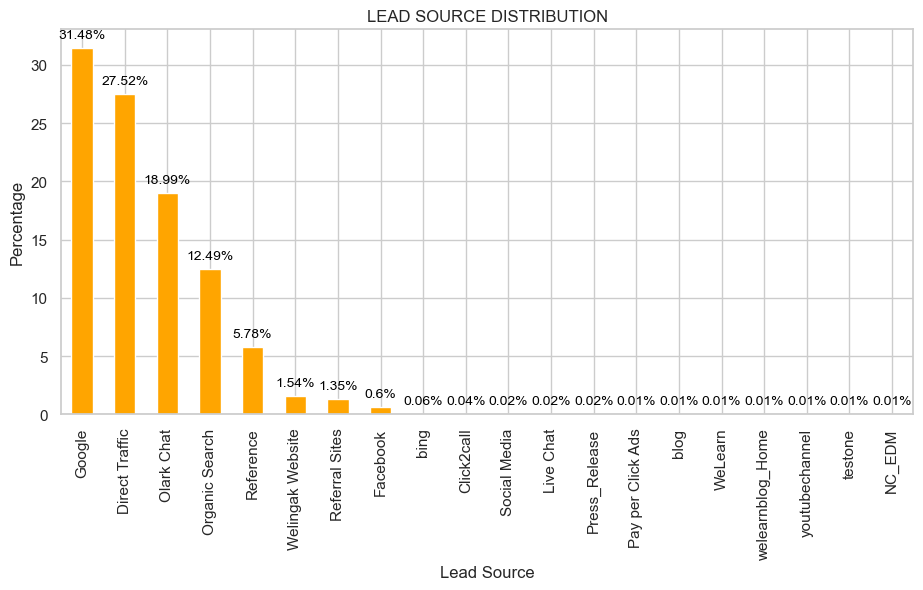

In [51]:
#plotting a bar graph for the same
bg = round(leads['Lead Source'].value_counts(normalize=True)*100, 2) #calculating percentage distribution of lead sources

plt.figure(figsize=(11, 5)) #setting figure size as 11*5
barplot = bg.plot.bar(color='orange') #plotting the bar graph

#labelling the axes
plt.title('LEAD SOURCE DISTRIBUTION')
plt.xlabel('Lead Source')
plt.ylabel('Percentage')

#annotating the bars with their corresponding values
for p in barplot.patches:
    barplot.annotate(f'{p.get_height()}%', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='bottom', fontsize=10, color='black', 
                      xytext=(0, 5),  # Offset the text by 5 points
                      textcoords='offset points')
    
plt.show() #displaying the graph

#### 'Converted' variable (Target)

In [52]:
#checking value_counts of the target variable 'Converted'
leads['Converted'].value_counts(normalize=True)*100

Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64

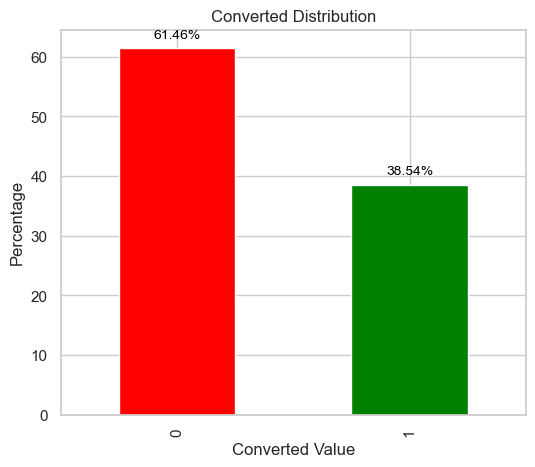

In [53]:
#plotting a bar graph for the same
cg = round(leads['Converted'].value_counts(normalize=True)*100, 2) #calculating percentage distribution of lead sources

plt.figure(figsize=(6,5)) #setting figure size as 11*5
barplot = cg.plot.bar(color=['red','green']) #plotting the bar graph

#labelling the axes
plt.title('Converted Distribution')
plt.xlabel('Converted Value')
plt.ylabel('Percentage')

#annotating the bars with their corresponding values
for p in barplot.patches:
    barplot.annotate(f'{p.get_height()}%', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='bottom', fontsize=10, color='black', 
                      xytext=(0, 5),  # Offset the text by 5 points
                      textcoords='offset points')
    
plt.show() #displaying the graph

Converted value 0 means that the lead could not be converted as a customer, and value 1 means that the lead has successfully been converted as a customer by purchasing a course.

We can see that the conversion percentage of X Education is 38.5%, which has to be improved.

#### 'TotalVisits' variable

In [54]:
#checking value_counts of column 'TotalVisits'
leads['TotalVisits'].value_counts()

TotalVisits
0.0      2189
2.0      1680
3.0      1443
4.0      1120
5.0       783
6.0       466
1.0       395
7.0       309
8.0       224
9.0       164
10.0      114
11.0       86
13.0       48
12.0       45
14.0       36
16.0       21
15.0       18
17.0       16
18.0       15
20.0       12
19.0        9
21.0        6
23.0        6
24.0        5
25.0        5
27.0        5
22.0        3
29.0        2
28.0        2
26.0        2
141.0       1
55.0        1
30.0        1
43.0        1
74.0        1
41.0        1
54.0        1
115.0       1
251.0       1
32.0        1
42.0        1
Name: count, dtype: int64

It is confusing to look at distribution individually here, hence, let us categorize the 'TotalVisits' column values into 6 bins - <br> 1. 0 to 50 <br> 2. 51 to 100 <br> 3. 101 to 150 <br> 4. 151 to 200 <br> 5. 201 to 250 <br> 6. 251 to 300.

In [55]:
#defining the bin edges
bins = [0, 51, 101, 151, 201, 251, 301]

#defining the bin labels
labels = ['0-50', '51-100', '101-150', '151-200', '201-250', '251-300']

#creating a new column with the categories
leads['TotalVisits_buckets'] = pd.cut(leads['TotalVisits'], bins=bins, labels=labels, right=False)

#checking if the bins have been formed or not
leads.head(10)

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,TotalVisits_buckets
0,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,...,No,No,No,No,No,No,No,No,Modified,0-50
1,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,...,No,No,No,No,No,No,No,No,Email Opened,0-50
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,...,No,No,No,No,No,No,No,Yes,Email Opened,0-50
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,...,No,No,No,No,No,No,No,No,Modified,0-50
4,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,...,No,No,No,No,No,No,No,No,Modified,0-50
5,660680,API,Olark Chat,No,No,0,0.0,0,0.0,Olark Chat Conversation,...,No,No,No,No,No,No,No,No,Modified,0-50
6,660673,Landing Page Submission,Google,No,No,1,2.0,1640,2.0,Email Opened,...,No,No,No,No,No,No,No,No,Modified,0-50
7,660664,API,Olark Chat,No,No,0,0.0,0,0.0,Olark Chat Conversation,...,No,No,No,No,No,No,No,No,Modified,0-50
8,660624,Landing Page Submission,Direct Traffic,No,No,0,2.0,71,2.0,Email Opened,...,No,No,No,No,No,No,No,Yes,Email Opened,0-50
9,660616,API,Google,No,No,0,4.0,58,4.0,Email Opened,...,No,No,No,No,No,No,No,No,Email Opened,0-50


In [56]:
#now let us check value_counts of column 'TotalVisits_buckets'
leads['TotalVisits_buckets'].value_counts().sort_values(ascending=False)

TotalVisits_buckets
0-50       9234
51-100        3
101-150       2
251-300       1
151-200       0
201-250       0
Name: count, dtype: int64

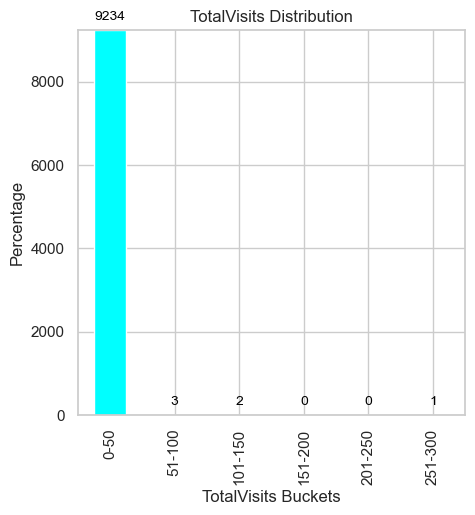

In [57]:
#plotting bar graph for the same
tv = leads['TotalVisits_buckets'].value_counts().sort_index()

plt.figure(figsize=(5, 5))
bar_plot = tv.plot.bar(color='cyan')

plt.title('TotalVisits Distribution')
plt.xlabel('TotalVisits Buckets')
plt.ylabel('Percentage')

for p in bar_plot.patches:
    bar_plot.annotate(f'{p.get_height()}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='bottom', fontsize=10, color='black', 
                      xytext=(0, 5),  # Offset the text by 5 points
                      textcoords='offset points')

#setting y-axis limits to show small values clearly
plt.ylim(0, max(tv) + 2)

plt.show()

#### 'Through Recommendations' variable

In [58]:
#checking value_counts of column 'Through Recommendations'
leads['Through Recommendations'].value_counts(normalize=True)*100

Through Recommendations
No     99.924242
Yes     0.075758
Name: proportion, dtype: float64

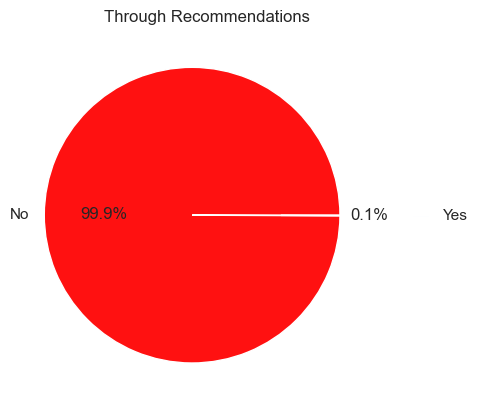

In [59]:
#plotting pie chart for the same

tr = leads['Through Recommendations'].value_counts(normalize=True)*100

# Define explode to highlight the 'Yes' slice (or any slice you choose)
explode = (0.1, 0.5)  # Only 'Yes' is exploded

# Define custom colors
colors = ['#ff1111', '#66b3ff']

plt.pie(tr, labels=['No','Yes'], autopct='%1.1f%%', colors=colors, explode=explode)
plt.title('Through Recommendations')
plt.show()

#### 'Total Time Spent on Website' variable

In [60]:
leads['Total Time Spent on Website'].value_counts()

Total Time Spent on Website
0       2193
60        19
74        18
75        18
127       18
        ... 
1701       1
1952       1
1229       1
1743       1
927        1
Name: count, Length: 1731, dtype: int64

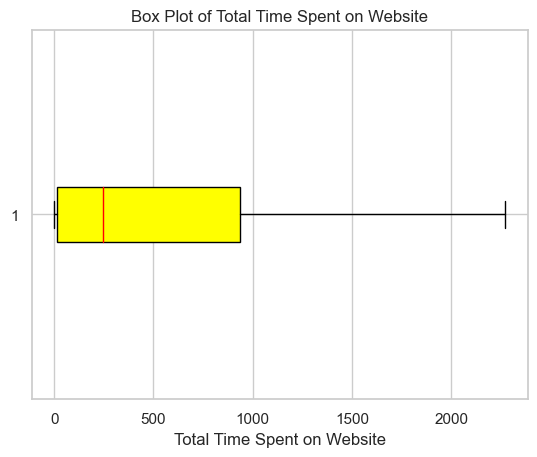

In [61]:
#creating a box plot for it

box = plt.boxplot(leads['Total Time Spent on Website'], vert=False, patch_artist=True)

#Set the fill color for the box
for patch in box['boxes']:
    patch.set_facecolor('yellow')  # Fill color for the box
    patch.set_edgecolor('black')  # Edge color for the box

#Set the median line color
for median in box['medians']:
    median.set_color('red')  #Median line color

#adding title and labels
plt.title('Box Plot of Total Time Spent on Website')
plt.xlabel('Total Time Spent on Website')

#showing the plot
plt.show()

#### Analyzing some more variables

Now, let us quickly inspect some other columns as well -   
<span style="background-color: #f0f0f0;">Receive More Updates About Our Courses</span>    
<span style="background-color: #f0f0f0;">I agree to pay the amount through cheque</span>    
<span style="background-color: #f0f0f0;">A free copy of Mastering The Interview</span>     
<span style="background-color: #f0f0f0;">Last Notable Activity</span>     
<span style="background-color: #f0f0f0;">Update me on Supply Chain Content</span> and     
<span style="background-color: #f0f0f0;">Get updates on DM Content</span>

In [62]:
leads['Receive More Updates About Our Courses'].value_counts()

Receive More Updates About Our Courses
No    9240
Name: count, dtype: int64

In [63]:
leads['I agree to pay the amount through cheque'].value_counts()

I agree to pay the amount through cheque
No    9240
Name: count, dtype: int64

In [64]:
leads['A free copy of Mastering The Interview'].value_counts()

A free copy of Mastering The Interview
No     6352
Yes    2888
Name: count, dtype: int64

In [65]:
leads['Last Notable Activity'].value_counts()

Last Notable Activity
Modified                        3407
Email Opened                    2827
SMS Sent                        2172
Page Visited on Website          318
Olark Chat Conversation          183
Email Link Clicked               173
Email Bounced                     60
Unsubscribed                      47
Unreachable                       32
Had a Phone Conversation          14
Email Marked Spam                  2
Approached upfront                 1
Resubscribed to emails             1
View in browser link Clicked       1
Form Submitted on Website          1
Email Received                     1
Name: count, dtype: int64

In [66]:
leads['Update me on Supply Chain Content'].value_counts()

Update me on Supply Chain Content
No    9240
Name: count, dtype: int64

In [67]:
leads['Get updates on DM Content'].value_counts()

Get updates on DM Content
No    9240
Name: count, dtype: int64

From the above, we can see that the data in these columns is highly skewed, and these columns serve no purpose to analysis.

Hence dropping all these irrelavant columns, except 'A free copy of Mastering The Interview' column, which seems to be of some value for analysis.

In [68]:
#dropping unnecessary columns
leads.drop(columns=['Through Recommendations',
                    'Receive More Updates About Our Courses',
                    'I agree to pay the amount through cheque', 
                    'Last Notable Activity', 
                    'Update me on Supply Chain Content', 
                    'Get updates on DM Content'], axis=1, inplace=True)

In [69]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   Lead Number                             9240 non-null   int64   
 1   Lead Origin                             9240 non-null   object  
 2   Lead Source                             9240 non-null   object  
 3   Do Not Email                            9240 non-null   object  
 4   Do Not Call                             9240 non-null   object  
 5   Converted                               9240 non-null   int64   
 6   TotalVisits                             9240 non-null   float64 
 7   Total Time Spent on Website             9240 non-null   int64   
 8   Page Views Per Visit                    9240 non-null   float64 
 9   Last Activity                           9240 non-null   object  
 10  Specialization                          9240 non

#### 'Do Not Email' & 'Do Not Call' variables

In [70]:
leads['Do Not Email'].value_counts()

Do Not Email
No     8506
Yes     734
Name: count, dtype: int64

In [71]:
leads['Do Not Call'].value_counts()

Do Not Call
No     9238
Yes       2
Name: count, dtype: int64

Itseems that these 2 columns are also unimportant and can be safely dropped.

In [72]:
#dropping the 2 columns
leads.drop(columns=['Do Not Email', 'Do Not Call'], axis=1, inplace=True)

#checking the df once again
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   Lead Number                             9240 non-null   int64   
 1   Lead Origin                             9240 non-null   object  
 2   Lead Source                             9240 non-null   object  
 3   Converted                               9240 non-null   int64   
 4   TotalVisits                             9240 non-null   float64 
 5   Total Time Spent on Website             9240 non-null   int64   
 6   Page Views Per Visit                    9240 non-null   float64 
 7   Last Activity                           9240 non-null   object  
 8   Specialization                          9240 non-null   object  
 9   What is your current occupation         9240 non-null   object  
 10  Search                                  9240 non

### b) Bivariate & Multivariate Analysis

Let us first plot a __Correlation Matrix__ for the numerical columns in the dataframe, to understand the relationships between them better.

In [73]:
#correlation matrix to understand correlation between attributes
numeric_cols = leads.select_dtypes(include=[np.number]) #filtering only numeric columns

correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                             Lead Number  Converted  TotalVisits  \
Lead Number                     1.000000   0.025157     0.021366   
Converted                       0.025157   1.000000     0.029119   
TotalVisits                     0.021366   0.029119     1.000000   
Total Time Spent on Website     0.020329   0.362483     0.217341   
Page Views Per Visit            0.057042  -0.005068     0.512214   

                             Total Time Spent on Website  Page Views Per Visit  
Lead Number                                     0.020329              0.057042  
Converted                                       0.362483             -0.005068  
TotalVisits                                     0.217341              0.512214  
Total Time Spent on Website                     1.000000              0.314266  
Page Views Per Visit                            0.314266              1.000000  


We can see the correlation between the row and column variables from the above matrix.     

But since the readability is not that great, it is better to plot a heatmap instead, which is easily understandable.

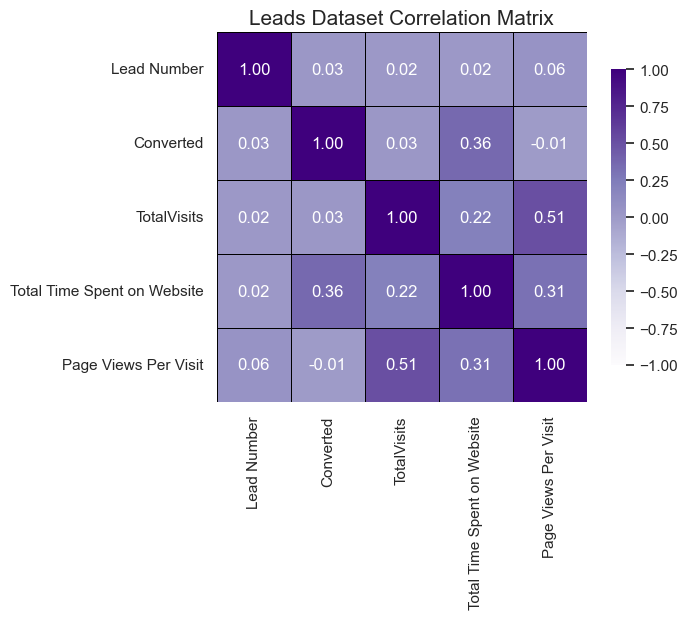

In [74]:
#creating a heatmap for the above correlation matrix
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='Purples', 
            square=True, 
            cbar_kws={"shrink": .8}, 
            linewidths=0.5,  # Add space between cells
            linecolor='black',  # Color of the lines (borders)
            vmin=-1, vmax=1)  # Set limits for color scaling

#adding titles and labels
plt.title('Leads Dataset Correlation Matrix', fontsize=15)
plt.show()

### 'Lead Origin' and 'Converted' variables

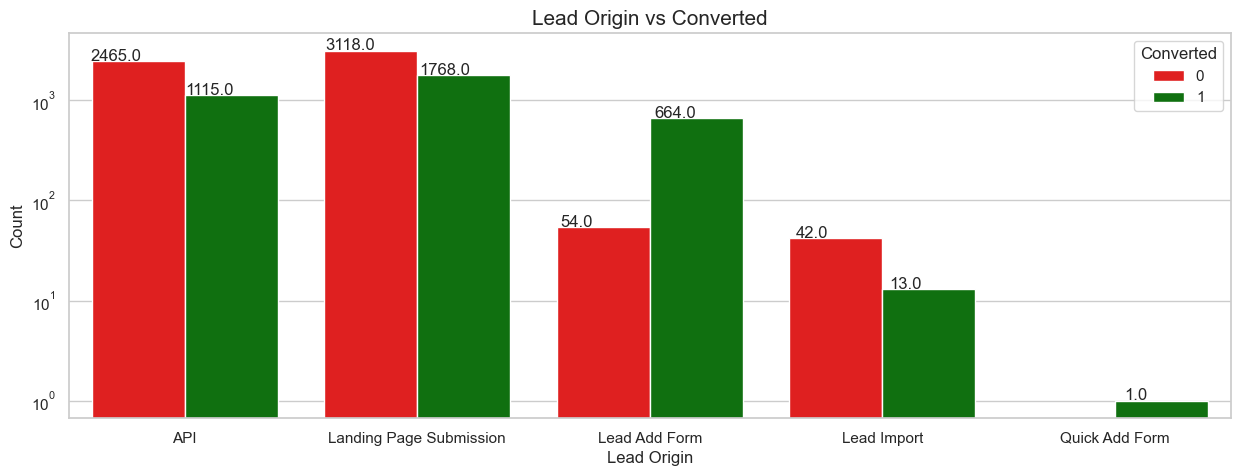

In [75]:
#plotting grouped bar graph for 'Lead Origin' and 'Converted'
plt.figure(figsize=(15,5))

loc = sns.countplot(x="Lead Origin", hue="Converted", data=leads, palette=['red','green'])

for p in loc.patches:
    loc.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('Lead Origin vs Converted',fontsize=15)
plt.xlabel('Lead Origin')
plt.ylabel('Count')

#setting y-scale to logarithmic values, for better readability
plt.yscale('log')

plt.show()

From above plot we can observe that the conversion rate is highest for 'Landing Page Submission', which is approximately 36% (1768 divided by 1768+3118). 'API' also has high number of conversions, approximately 31%. 'Lead Add Form' also has high number of conversions, which is greater than its number of unsuccessful conversions.

So in order to increase the overall conversion rate, we need to -      
    1. Focus on converting leads with origin __Landing Page Submission__ and __API__, and <br>
    2. Generate more leads from __Lead Add Form__

### 'Lead Source' and 'Converted' variables

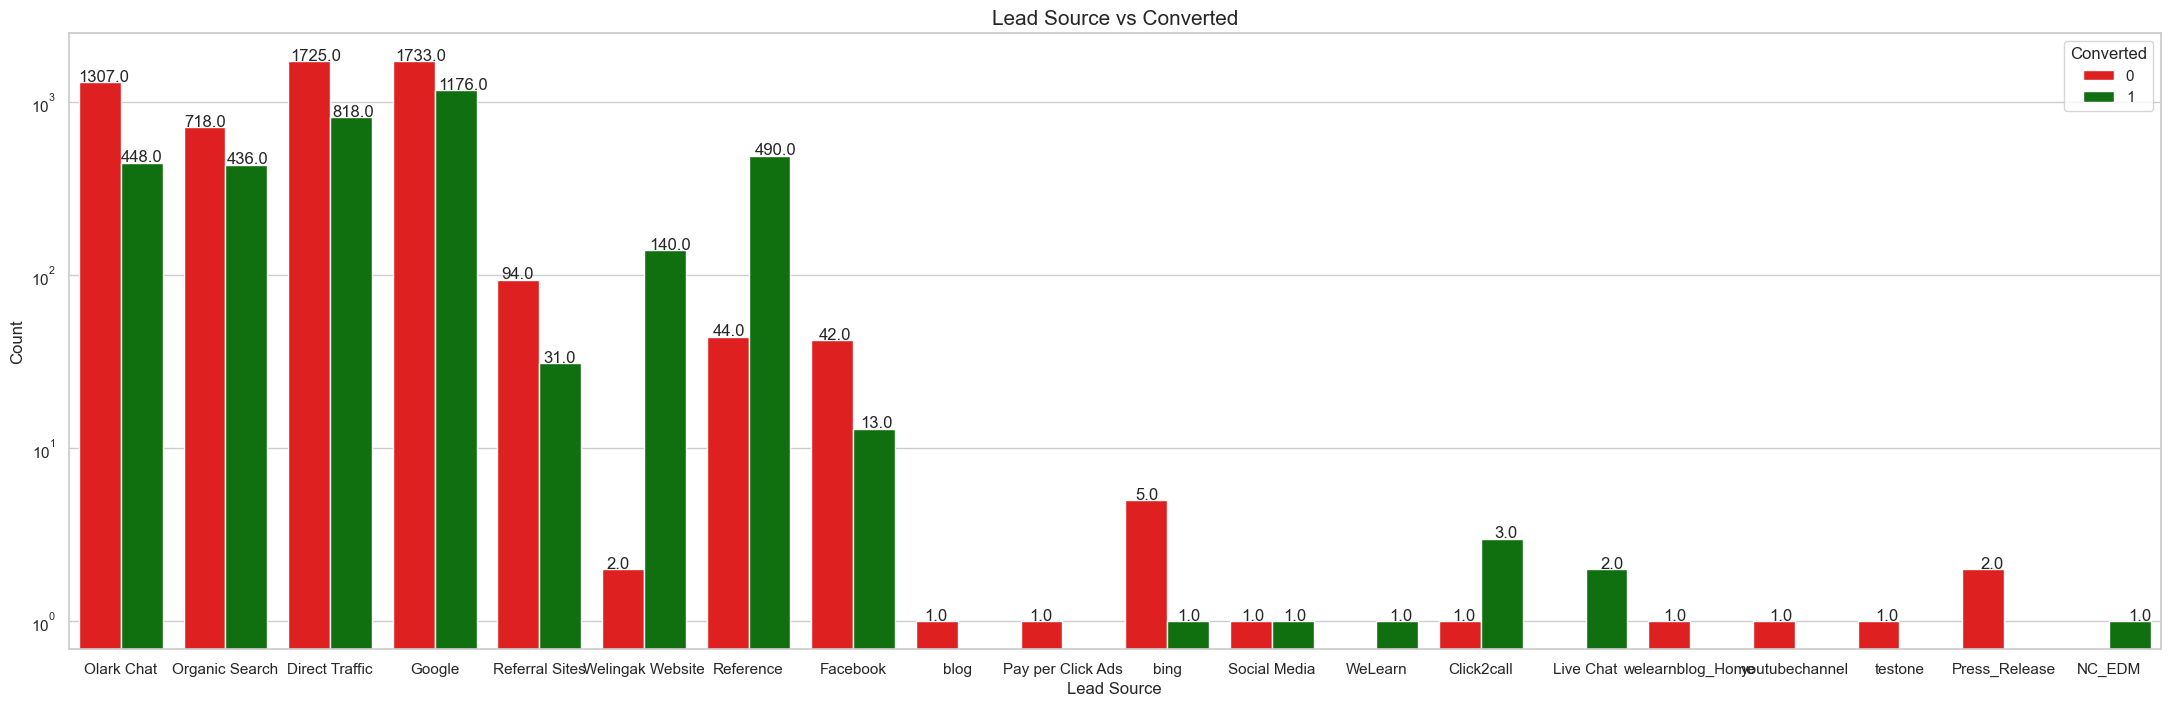

In [76]:
#plotting grouped bar graph for 'Lead Source' and 'Converted'
plt.figure(figsize=(27,8))

lsc = sns.countplot(x="Lead Source", hue="Converted", data=leads, palette=['red','green'])

for p in lsc.patches:
    lsc.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('Lead Source vs Converted',fontsize=15)
plt.xlabel('Lead Source')
plt.ylabel('Count')

#setting y-scale to logarithmic values, for better readability
plt.yscale('log')

plt.show()

As seen above, there are too many values for 'Lead Source' variable. It is difficult to plot them all on the graph.    
So, to improve the graph's readability, we can group all low frequency values under a new value called 'Others' and then plot the graph.

In [77]:
#grouping all low frequency values under 'Others' category
leads['Lead Source'] = leads['Lead Source'].replace(['blog','Pay per Click Ads','bing',
                                                     'Social Media','WeLearn','Click2call', 
                                                     'Live Chat','welearnblog_Home', 'youtubechannel',
                                                     'testone','Press_Release','NC_EDM'], 'Others')

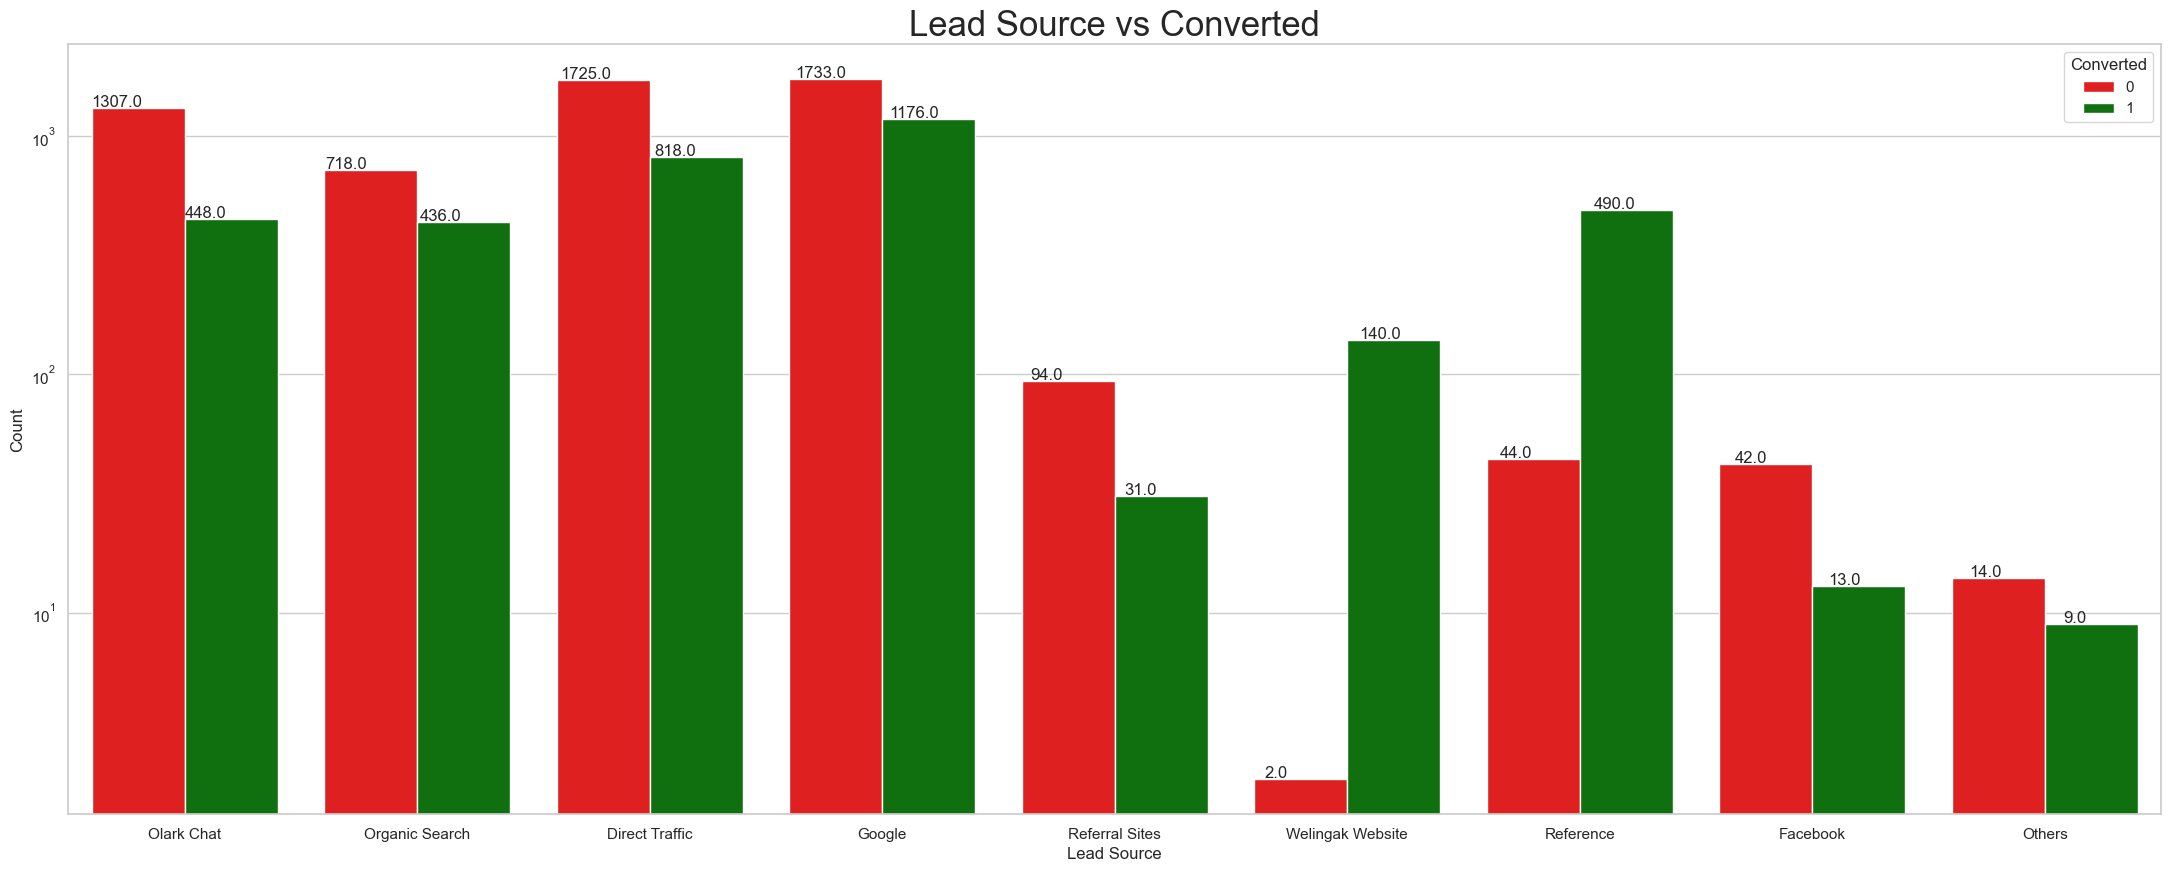

In [78]:
#replotting 'Lead Source' vs 'Converted' using sns countplot
plt.figure(figsize=(27,10))

lsc1 = sns.countplot(x="Lead Source", hue="Converted", data=leads, palette=['red','green'])

for p in lsc1.patches:
    lsc1.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('Lead Source vs Converted',fontsize=25)
plt.xlabel('Lead Source')
plt.ylabel('Count')

#setting y-scale to logarithmic values, for better readability
plt.yscale('log')

plt.show()

From above plot we can observe that -     
    1. 'Google' and 'Direct traffic' are the sources for maximum number of leads.
    2. 'Reference' and 'Welingak Website' have highest conversion rates, much more than unsuccessful conversions.

To improve overall lead conversion rate, we should -    
    1. Focus mainly on converting leads from __Google__, __Direct Traffic__, __Olark Chat__ and __Organic Search__, and also   
    2. Generate more leads from __Welingak Website__ and __Reference__.

### 'Last Activity' and 'Converted' variables

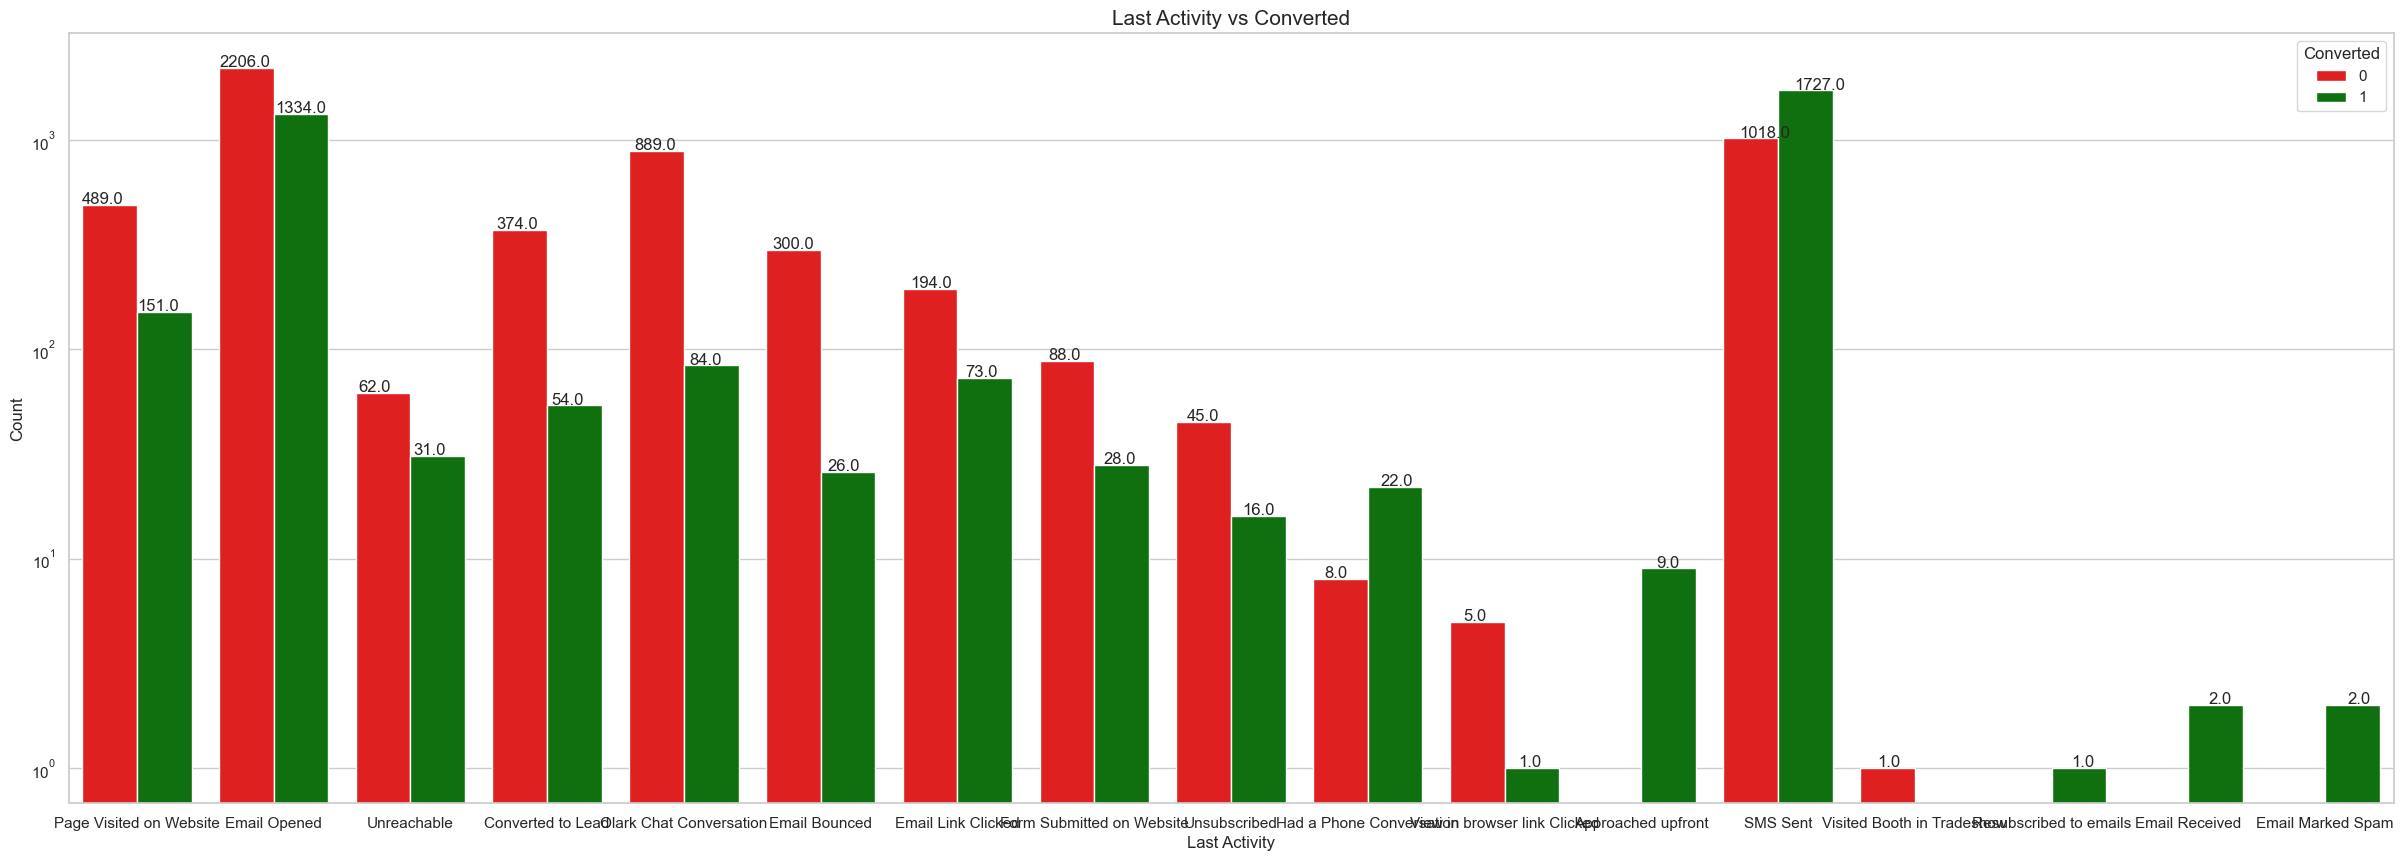

In [79]:
#plotting grouped bar graph for 'Last Activity' and 'Converted'

plt.figure(figsize=(30,10))

lac=sns.countplot(x="Last Activity", hue="Converted", data=leads, palette=['red','green'])

for p in lac.patches:
    lac.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('Last Activity vs Converted',fontsize=15)
plt.xlabel('Last Activity')
plt.ylabel('Count')

#setting y-scale to logarithmic values, for better readability
plt.yscale('log')

plt.show()

Let us take a similar approach as above by grouping all low frequency values under 'Others', to improve graph's readability.

In [80]:
#grouping all low count values as 'Others'
leads['Last Activity'] = leads['Last Activity'].replace(['Had a Phone Conversation','View in browser link Clicked',
                                                         'Visited Booth in Tradeshow','Approached upfront',
                                                         'Resubscribed to emails','Email Received',
                                                         'Email Marked Spam'],'Others')

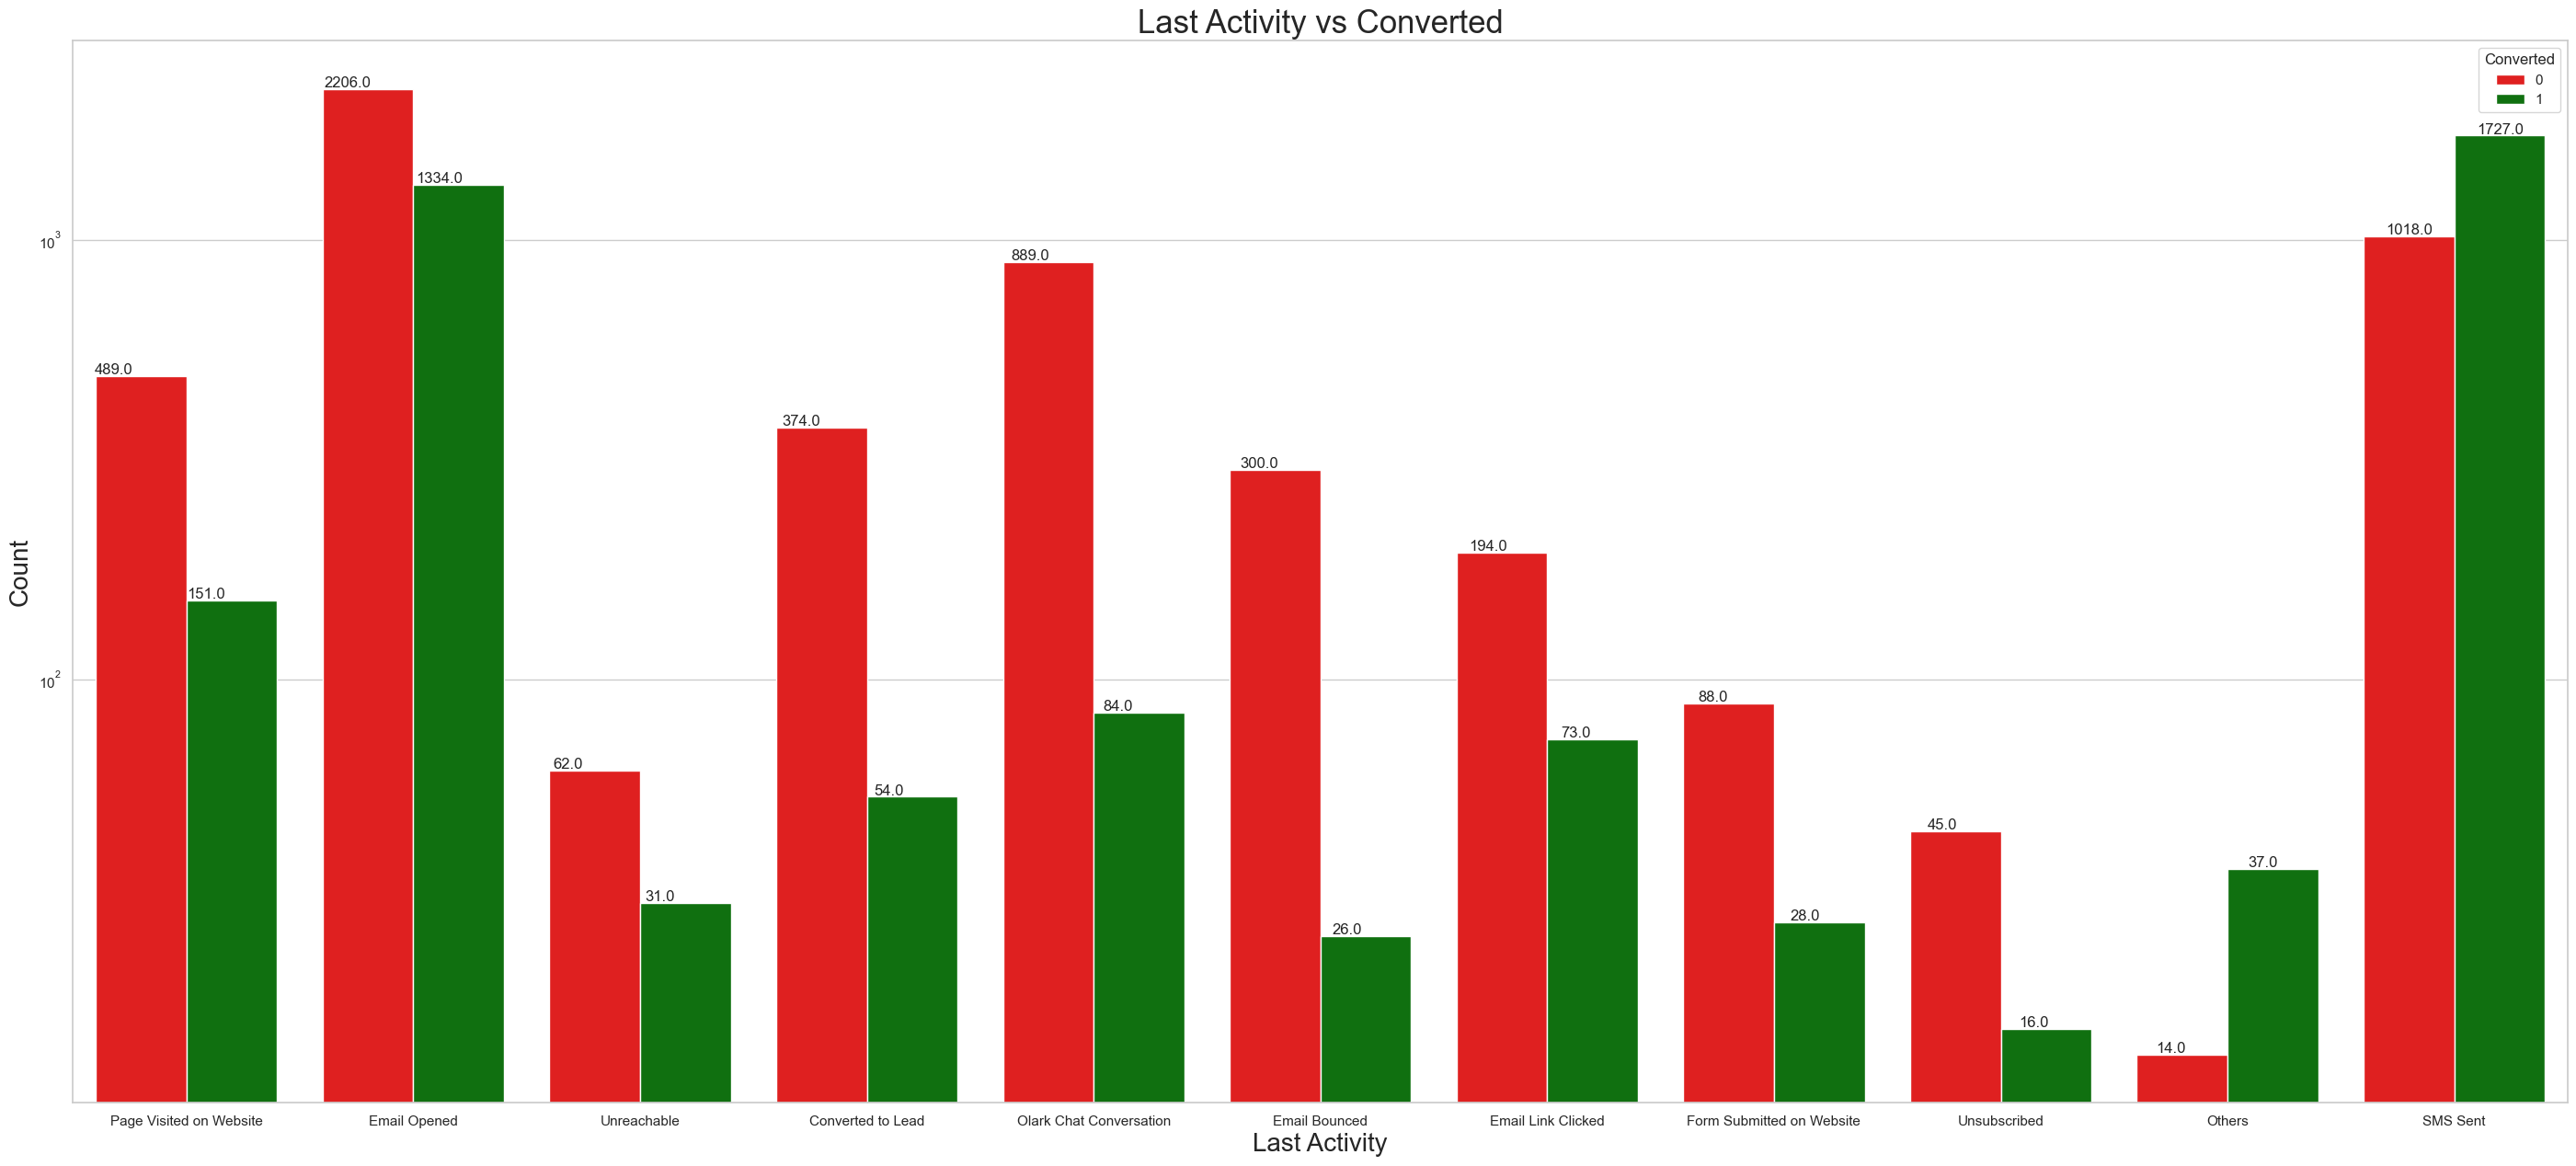

In [81]:
#replotting Last Activity' vs 'Converted' after recategorizing
plt.figure(figsize=(35,15))

lac1=sns.countplot(x="Last Activity", hue="Converted", data=leads, palette=['red','green'])

for p in lac1.patches:
    lac1.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('Last Activity vs Converted',fontsize=25)
plt.xlabel('Last Activity', fontsize=20)
plt.ylabel('Count', fontsize=20)

#setting y-scale to logarithmic values, for better readability
plt.yscale('log')

plt.show()

We can see that -
- Conversion rate for last activity of _SMS Sent_ is very high, approximately 63%, and   
- Conversion rate of leads with last activity as _Email Opened_ is also high, approximately 37%

So to improve the overall lead conversion rate, the Sales team should mainly pursue leads whose last activity is either __Email Opened__ or __SMS Sent__, especially the latter.

### 'What is your current occupation' and 'Converted' variables

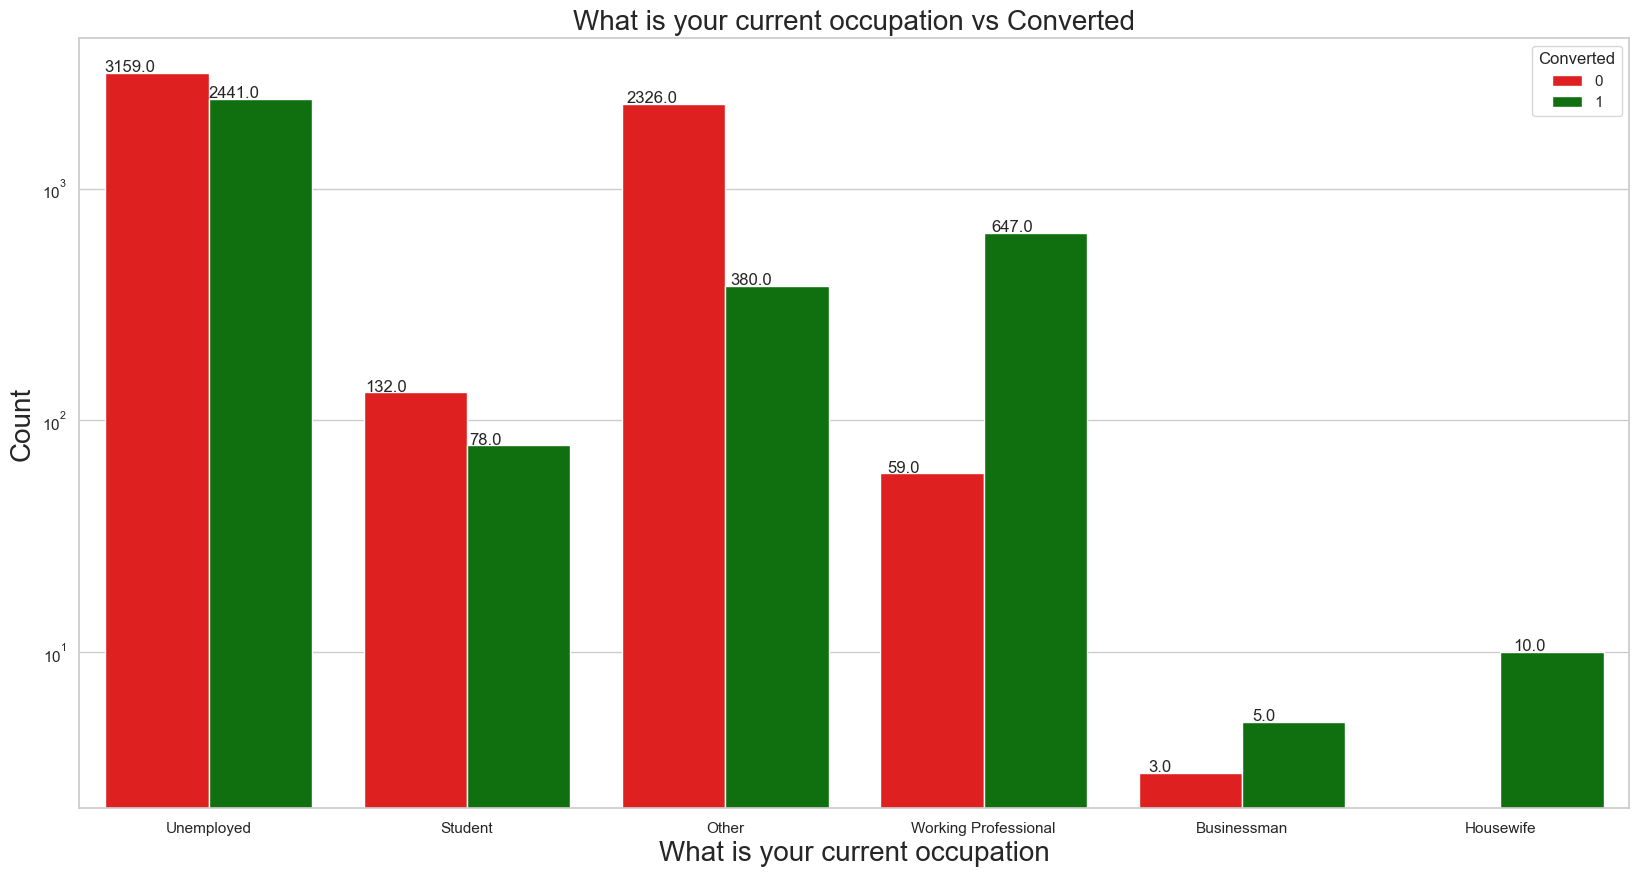

In [82]:
#plotting for 'What is your current occupation' vs 'Converted'
plt.figure(figsize=(20,10))

woc=sns.countplot(x="What is your current occupation", hue="Converted", data=leads, palette=['red','green'])

for p in woc.patches:
    woc.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('What is your current occupation vs Converted',fontsize=20)
plt.xlabel('What is your current occupation', fontsize=20)
plt.ylabel('Count', fontsize=20)

#setting y-scale to logarithmic values, for better readability
plt.yscale('log')

plt.show()

We can see that - 
 - Maximum number of leads from <span style="background-color: #f0f0f0;">Unemployed</span> people, who also have a good conversion rate of 45%.
 - Conversion rate is highest for <span style="background-color: #f0f0f0;">Working Professionals</span> (91.6%), and is high for <span style="background-color: #f0f0f0;">Unemployed</span> and <span style="background-color: #f0f0f0;">Student</span> as well.
 
So to improve overall lead conversion rate, the Sales team should -      
- Pursue Working Professionals, Students and Unemployed people, who are most likely to convert into customers.     
- Not spend much time pursuing Businessmen.

### 'Specialization' and 'Converted' variables

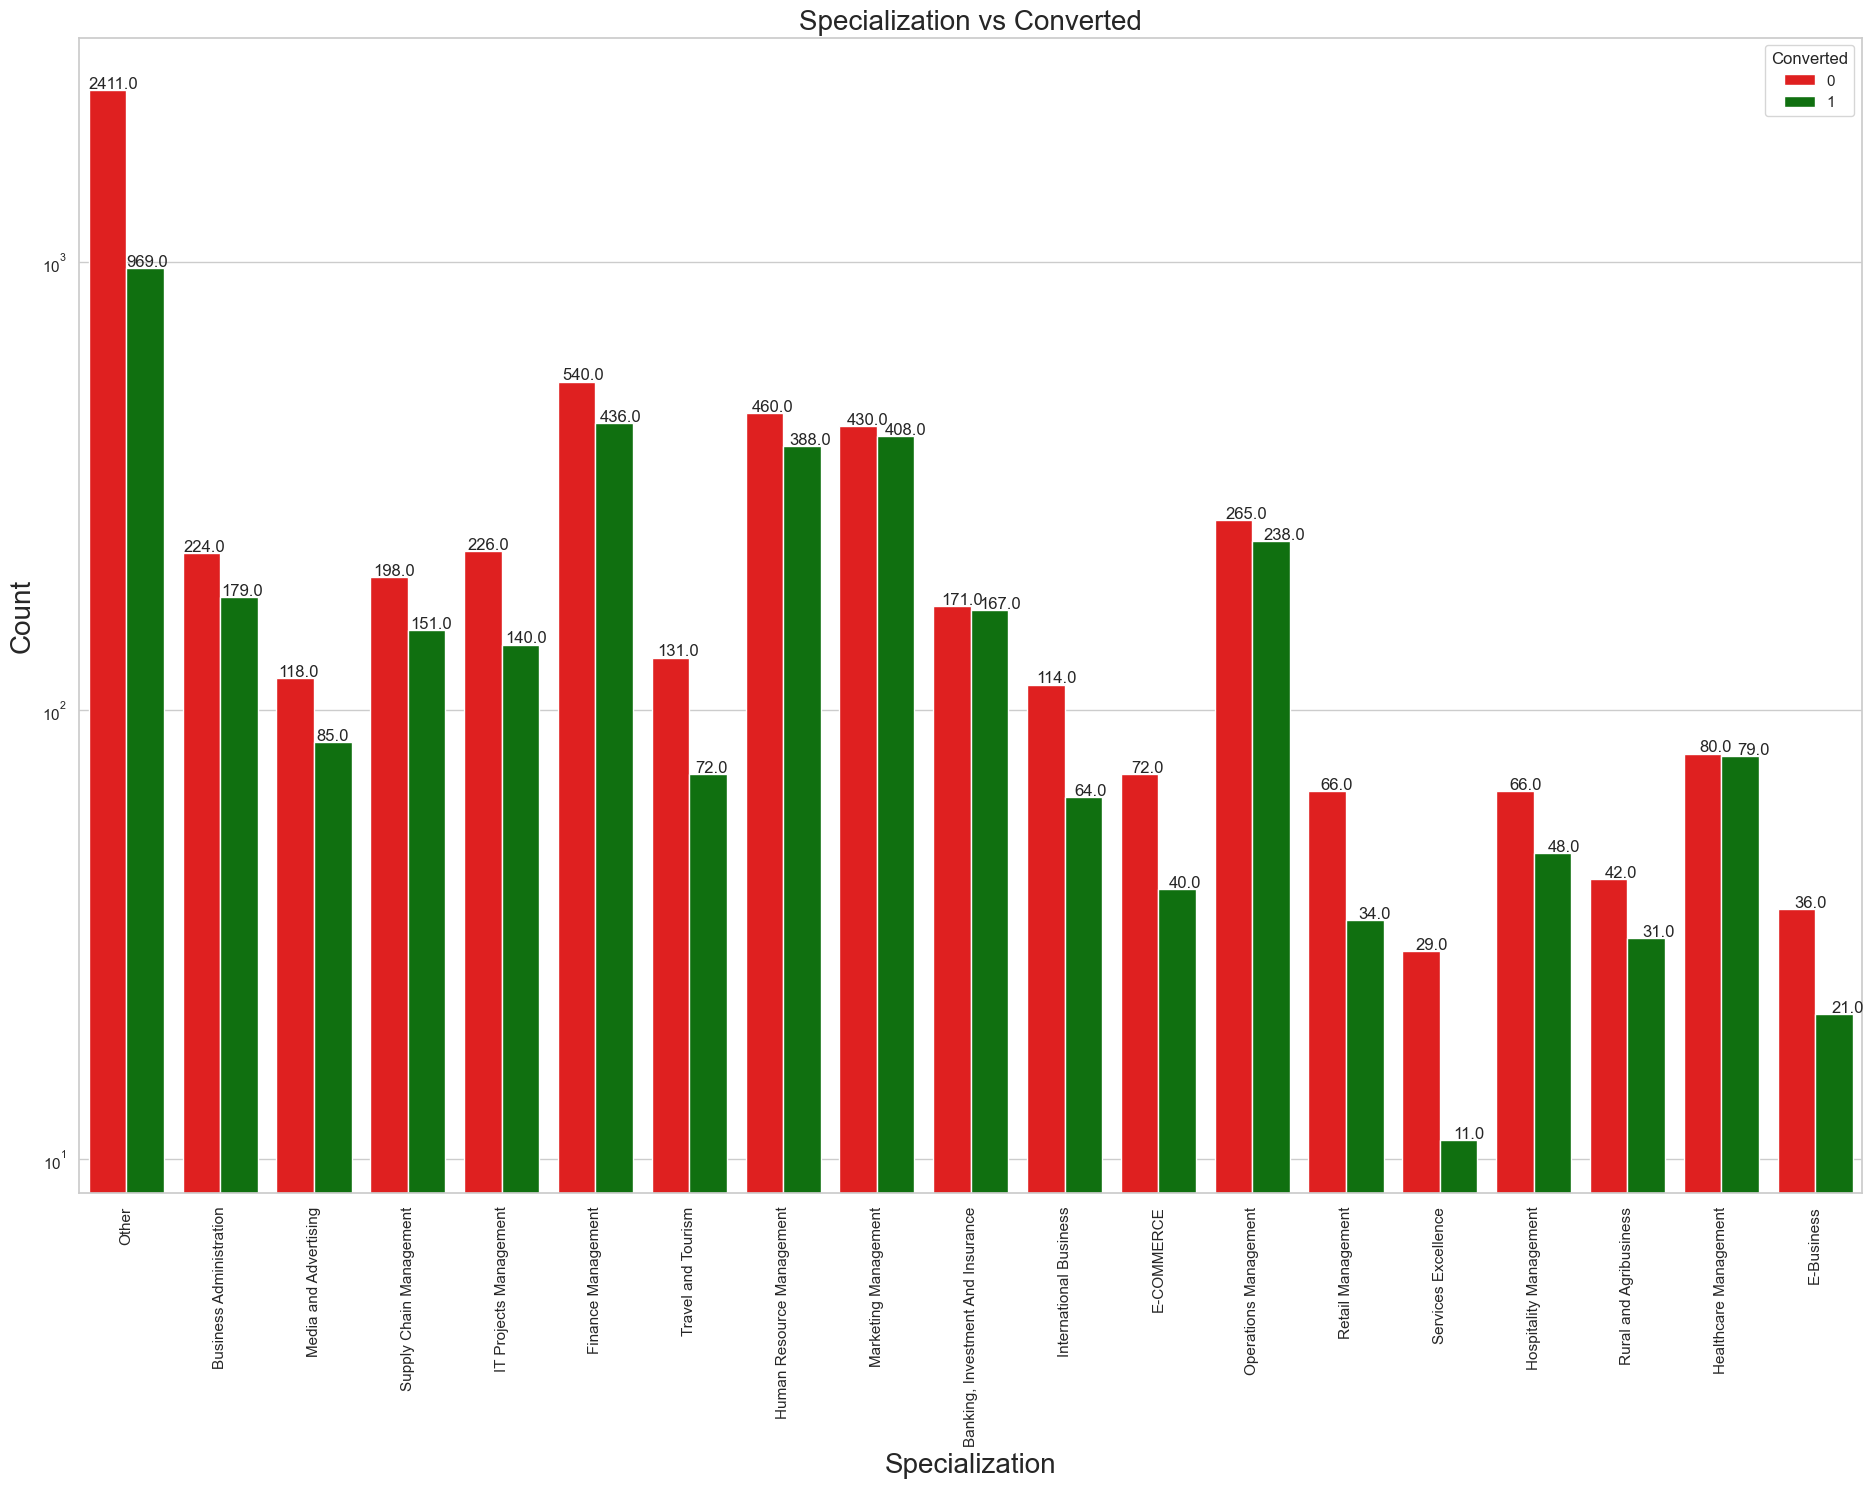

In [83]:
#plotting for 'Specialization' vs 'Converted'
plt.figure(figsize=(23,15))

sc=sns.countplot(x="Specialization", hue="Converted", data=leads, palette=['red','green'])

for p in sc.patches:
    sc.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('Specialization vs Converted',fontsize=20)
plt.xlabel('Specialization', fontsize=20)
plt.ylabel('Count', fontsize=20)

#setting y-scale to logarithmic values, for better readability
plt.xticks(rotation = 90)
plt.yscale('log')

plt.show()

The graph is clear enough. 
So we can see that Management and Others specializations constitute the maximum number of leads, and their conversion rates are also good.  

E-commerce, Service Excellences and E-Business specializations have the least number of leads. Hence it is better not to pursue people with background in these fields.

### 'Total Time Spent on Website' and 'Converted' variables

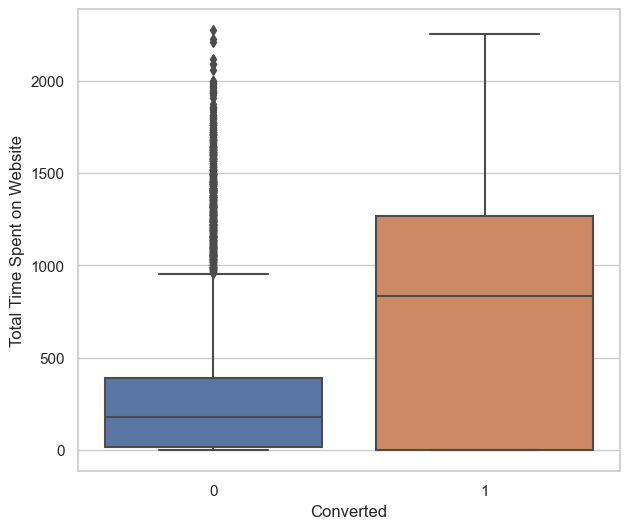

In [84]:
#plotting box plots of "Total Time Spent on Website" vs 'Converted' variables
plt.figure(figsize=(7,6))
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=leads)
plt.show()

It is obvious from the above plot that successfully converted leads (value 1) have a high Total Time Spent on Website count. 

Hence, leads spending more time on the website are most likely to convert and purchase courses.

### 'A free copy of Mastering The Interview' and 'Converted' variables

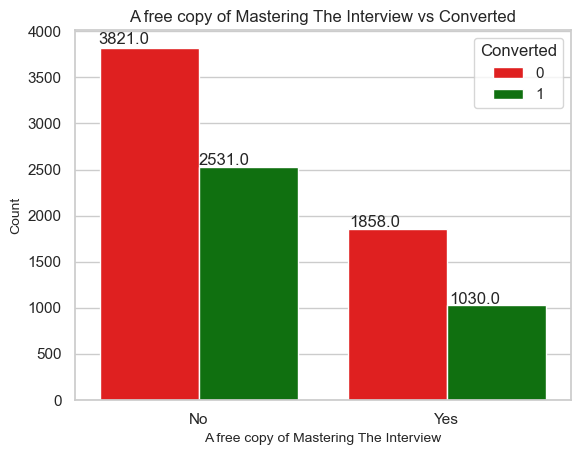

In [85]:
#plotting for 'A free copy of Mastering The Interview' vs 'Converted'
#plt.figure(figsize=(5,5))

afc=sns.countplot(x="A free copy of Mastering The Interview", hue="Converted", data=leads, palette=['red','green'])

for p in afc.patches:
    afc.annotate(str(p.get_height()), (p.get_x()*1.01 , p.get_height()*1.01))

plt.title('A free copy of Mastering The Interview vs Converted',fontsize=12)
plt.xlabel('A free copy of Mastering The Interview', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.show()

Conversion rate for 'Yes' is approximately 36%, while it is 40% for 'No'.

This means that there is no correlation between people who opted to take a free copy of the book 'Mastering The Interview' and their conversion rates. 

The act of opting for this book does not indicate their seriousness about purchasing courses at X Education in any way.

### Data Preparation for Model Building

Let us replace the values in this variable with 0s and 1s, for convenience during model building.

In [86]:
#replacing the values of 'A free copy of Mastering The Interview' column with 0s and 1s
leads['A free copy of Mastering The Interview'] = leads['A free copy of Mastering The Interview'].map({'Yes': 1, "No": 0})

In [87]:
#checking the column after replacing
leads['A free copy of Mastering The Interview'].value_counts()

A free copy of Mastering The Interview
0    6352
1    2888
Name: count, dtype: int64

Now, let us filter out all categorical variables from the dataframe, for future analysis.

In [88]:
#filtering out categorical columns into a list
categorical_cols = leads.select_dtypes(include=['object']).columns
categorical_cols

Index(['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization',
       'What is your current occupation', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement'],
      dtype='object')

Let us drop some unimportant columns from the df.

In [89]:
#dropping the columns
leads.drop(columns=['Search', 'Magazine', 'Newspaper Article', 'X Education Forums',
                    'Newspaper', 'Digital Advertisement'], axis=1, inplace=True)

#checking the df once again
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   Lead Number                             9240 non-null   int64   
 1   Lead Origin                             9240 non-null   object  
 2   Lead Source                             9240 non-null   object  
 3   Converted                               9240 non-null   int64   
 4   TotalVisits                             9240 non-null   float64 
 5   Total Time Spent on Website             9240 non-null   int64   
 6   Page Views Per Visit                    9240 non-null   float64 
 7   Last Activity                           9240 non-null   object  
 8   Specialization                          9240 non-null   object  
 9   What is your current occupation         9240 non-null   object  
 10  A free copy of Mastering The Interview  9240 non

For some categorical columns from the above output, we will create dummy variables which will help us build the model.

A dummy variable is a binary (0 or 1) variable created for each category in a categorical variable.

In [90]:
#creating dummy variables for the above-mentioned categorical variables, and forming a new df
dummy_df = pd.get_dummies(leads[['Lead Origin', 'Lead Source', 'Last Activity',
                                 'What is your current occupation','Specialization']], drop_first=True)

#displaying the top 5 rows of the dummy df
dummy_df.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,...,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Other,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,True,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [91]:
#merging the original and dummy dfs together
leads = pd.concat([dummy_df,leads], axis=1)

In [92]:
leads.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,...,Lead Source,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,A free copy of Mastering The Interview,TotalVisits_buckets
0,False,False,False,False,False,False,True,False,False,False,...,Olark Chat,0,0.0,0,0.0,Page Visited on Website,Other,Unemployed,0,0-50
1,False,False,False,False,False,False,False,True,False,False,...,Organic Search,0,5.0,674,2.5,Email Opened,Other,Unemployed,0,0-50
2,True,False,False,False,False,False,False,False,False,False,...,Direct Traffic,1,2.0,1532,2.0,Email Opened,Business Administration,Student,1,0-50
3,True,False,False,False,False,False,False,False,False,False,...,Direct Traffic,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,0,0-50
4,True,False,False,False,False,True,False,False,False,False,...,Google,1,2.0,1428,1.0,Converted to Lead,Other,Unemployed,0,0-50


In [93]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 57 columns):
 #   Column                                                Non-Null Count  Dtype   
---  ------                                                --------------  -----   
 0   Lead Origin_Landing Page Submission                   9240 non-null   bool    
 1   Lead Origin_Lead Add Form                             9240 non-null   bool    
 2   Lead Origin_Lead Import                               9240 non-null   bool    
 3   Lead Origin_Quick Add Form                            9240 non-null   bool    
 4   Lead Source_Facebook                                  9240 non-null   bool    
 5   Lead Source_Google                                    9240 non-null   bool    
 6   Lead Source_Olark Chat                                9240 non-null   bool    
 7   Lead Source_Organic Search                            9240 non-null   bool    
 8   Lead Source_Others                              

In [94]:
#dropping repeated columns for which dummy variables were created
leads.drop(['Lead Origin','Lead Source','Last Activity','What is your current occupation','Specialization'], axis=1, inplace = True)

In [95]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 52 columns):
 #   Column                                                Non-Null Count  Dtype   
---  ------                                                --------------  -----   
 0   Lead Origin_Landing Page Submission                   9240 non-null   bool    
 1   Lead Origin_Lead Add Form                             9240 non-null   bool    
 2   Lead Origin_Lead Import                               9240 non-null   bool    
 3   Lead Origin_Quick Add Form                            9240 non-null   bool    
 4   Lead Source_Facebook                                  9240 non-null   bool    
 5   Lead Source_Google                                    9240 non-null   bool    
 6   Lead Source_Olark Chat                                9240 non-null   bool    
 7   Lead Source_Organic Search                            9240 non-null   bool    
 8   Lead Source_Others                              

Since we need only numerical columns for further model building, let us delete the 'TotalVisits_buckets' variable.
It is no longer needed now and is unsuitable for feature scaling.

In [96]:
leads.drop(['TotalVisits_buckets'], axis=1, inplace=True)

leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Lead Origin_Landing Page Submission                   9240 non-null   bool   
 1   Lead Origin_Lead Add Form                             9240 non-null   bool   
 2   Lead Origin_Lead Import                               9240 non-null   bool   
 3   Lead Origin_Quick Add Form                            9240 non-null   bool   
 4   Lead Source_Facebook                                  9240 non-null   bool   
 5   Lead Source_Google                                    9240 non-null   bool   
 6   Lead Source_Olark Chat                                9240 non-null   bool   
 7   Lead Source_Organic Search                            9240 non-null   bool   
 8   Lead Source_Others                                    9240

As we can observe above, all we have are just numerical columns. All the categorical columns have been replaced.

## 4. Train-Test Split

Defining what variables will go into our model - that is, the feature variables (independent variables) and target variable (dependent variable).

In [97]:
#making the feature variable as X (independent variables)
X = leads.drop(['Converted'], axis=1) #assigning all columns of the df, except the 'Converted' column

#displaying
X.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,...,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,Lead Number,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,660737,0.0,0,0.0,0
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,660728,5.0,674,2.5,0
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,660727,2.0,1532,2.0,1
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,660719,1.0,305,1.0,0
4,True,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,660681,2.0,1428,1.0,0


In [98]:
#making target variable as y
y = leads['Converted']

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Converted, dtype: int64

In [99]:
#splitting the data into train and test with ratio 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [100]:
#checking the sizes of each one
X_train.shape

(6468, 50)

In [101]:
X_test.shape

(2772, 50)

## 5. Feature Scaling

Scaling is important in machine learning, especially for algorithms that are sensitive to the scale of the data, like Linear Regression, Logistic Regression etc. By scaling the features, we ensure that all features contribute equally to the distance calculations and optimization processes.

Hence, let us first scale our data using 'StandardScaler'.

In [102]:
#creating 'scaler' object for 'StandardScaler'
scaler = StandardScaler()

#applying 'fit_transform' for scaling the 'train' data
X_train[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.fit_transform(X_train[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])

#checking
X_train.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,...,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,Lead Number,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview
1871,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,641410,-0.656434,-0.885371,-1.085519,0
6795,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,597687,0.100767,0.005716,-0.470569,1
3516,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,626825,0.290067,-0.691418,0.070401,0
8105,True,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,587928,0.290067,1.365219,1.226321,0
3934,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,622366,-0.656434,-0.885371,-1.085519,0


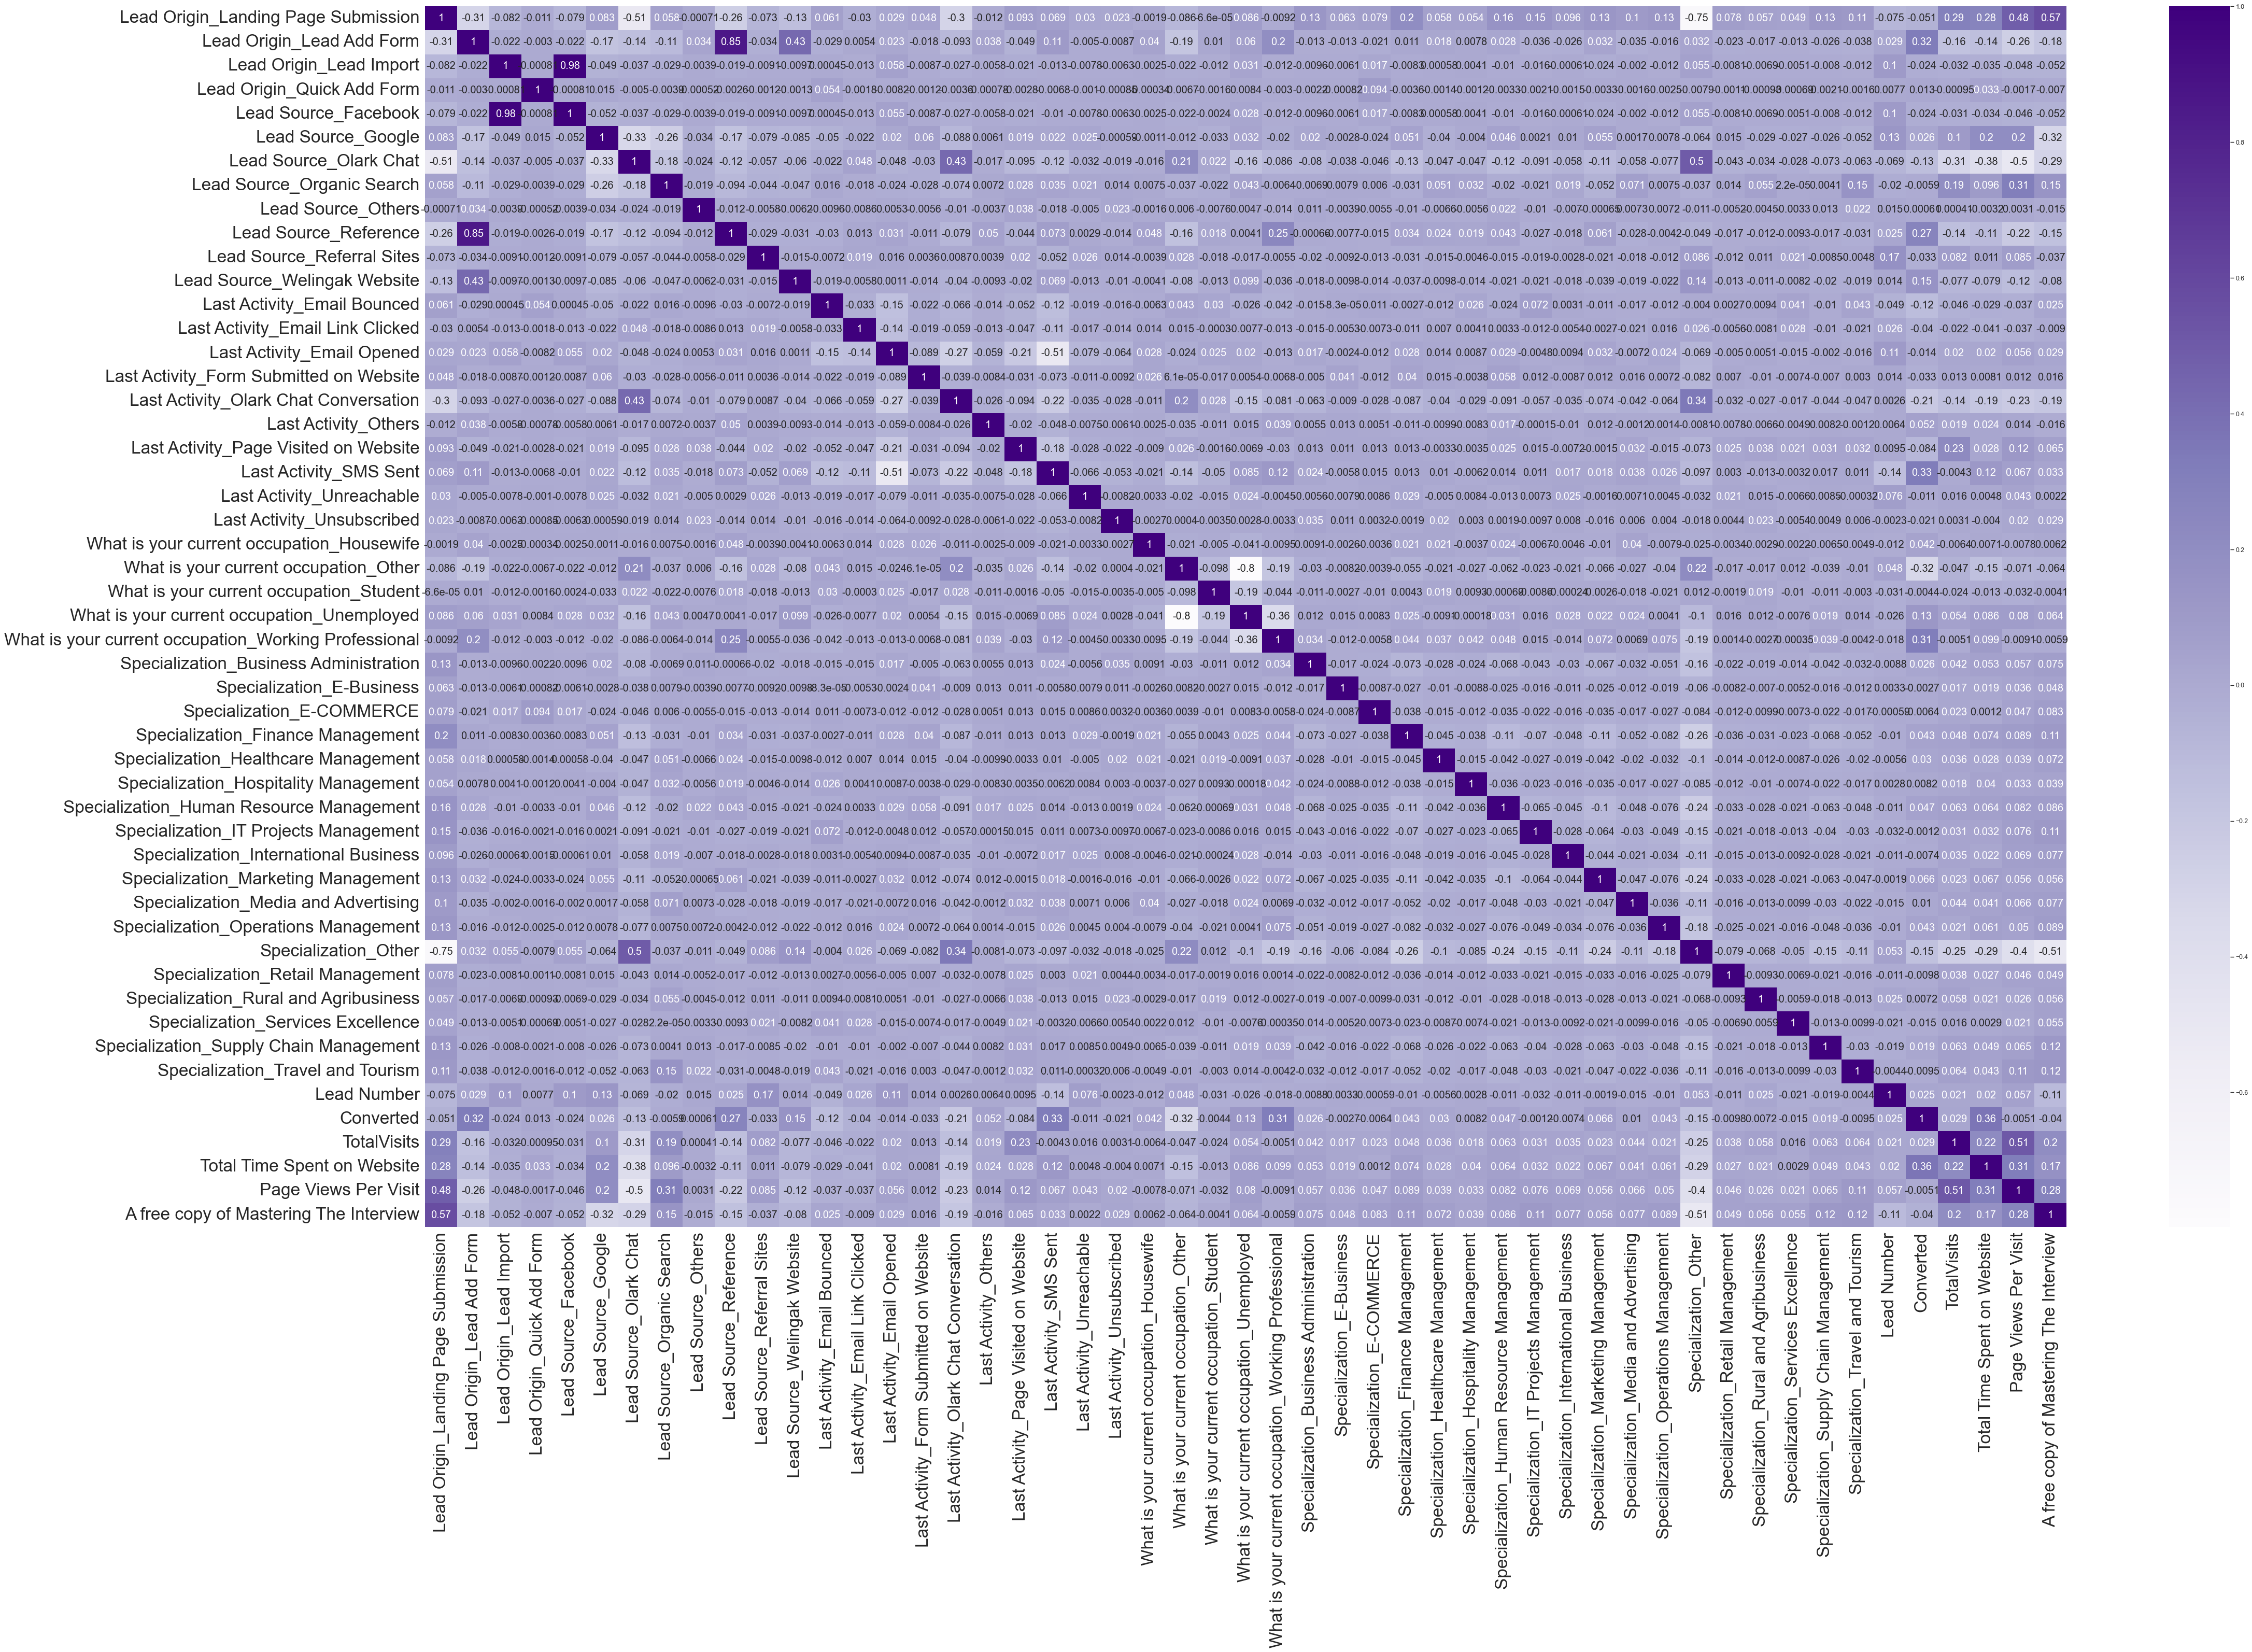

In [103]:
#plotting heatap to check the correlation coefficients among variables
plt.figure(figsize=(60,40),dpi=80)
sns.heatmap(leads.corr(), annot = True, cmap="Purples",annot_kws={"size": 18})
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.show()

The above heatmap clearly shows that - 
- 'Lead Origin_Lead Add Form' and 'Lead Source_Reference' have a high correlation of 0.85
- 'Lead Source_Facebook' and 'Lead Origin_Lead Import' have a high correlation of 0.98
- 'Lead Origin_Landing Page Submission' and 'A Free Copy of Mastering the Interview' also have a good correlation of 0.57.

So on the whole -   
- 'Lead Origin_Lead Add Form'
- 'Lead Source_Welingak Website' 
- 'Last Activity_SMS Sent' and
- 'What is your current Occupation_Working Professionals'     

have positive correlation with the target variable 'Converted'.

## 6. Model Building 

In [104]:
#creating LogisticRegression Object 'reg'
reg = LogisticRegression()

In [105]:
rfe = RFE(estimator=reg, n_features_to_select=15)  # running RFE with 15 variables as output
rfe = rfe.fit(X_train, y_train)

In [106]:
#displaying columns selected by RFE and their weights
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('Lead Origin_Landing Page Submission', True, 1),
 ('Lead Origin_Lead Add Form', True, 1),
 ('Lead Origin_Lead Import', False, 20),
 ('Lead Origin_Quick Add Form', False, 36),
 ('Lead Source_Facebook', False, 19),
 ('Lead Source_Google', False, 34),
 ('Lead Source_Olark Chat', True, 1),
 ('Lead Source_Organic Search', False, 5),
 ('Lead Source_Others', False, 35),
 ('Lead Source_Reference', True, 1),
 ('Lead Source_Referral Sites', False, 15),
 ('Lead Source_Welingak Website', False, 4),
 ('Last Activity_Email Bounced', False, 3),
 ('Last Activity_Email Link Clicked', False, 8),
 ('Last Activity_Email Opened', True, 1),
 ('Last Activity_Form Submitted on Website', False, 13),
 ('Last Activity_Olark Chat Conversation', True, 1),
 ('Last Activity_Others', False, 12),
 ('Last Activity_Page Visited on Website', True, 1),
 ('Last Activity_SMS Sent', True, 1),
 ('Last Activity_Unreachable', False, 24),
 ('Last Activity_Unsubscribed', False, 21),
 ('What is your current occupation_Housewife'

In [107]:
#storing columns selected by RFE into 'col' and displaying it
col = X_train.columns[rfe.support_]
col

Index(['Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form',
       'Lead Source_Olark Chat', 'Lead Source_Reference',
       'Last Activity_Email Opened', 'Last Activity_Olark Chat Conversation',
       'Last Activity_Page Visited on Website', 'Last Activity_SMS Sent',
       'What is your current occupation_Other',
       'What is your current occupation_Unemployed',
       'What is your current occupation_Working Professional',
       'Specialization_Other', 'Lead Number', 'Total Time Spent on Website',
       'A free copy of Mastering The Interview'],
      dtype='object')

In [108]:
#displaying columns which are not selected by RFE
X_train.columns[~rfe.support_]

Index(['Lead Origin_Lead Import', 'Lead Origin_Quick Add Form',
       'Lead Source_Facebook', 'Lead Source_Google',
       'Lead Source_Organic Search', 'Lead Source_Others',
       'Lead Source_Referral Sites', 'Lead Source_Welingak Website',
       'Last Activity_Email Bounced', 'Last Activity_Email Link Clicked',
       'Last Activity_Form Submitted on Website', 'Last Activity_Others',
       'Last Activity_Unreachable', 'Last Activity_Unsubscribed',
       'What is your current occupation_Housewife',
       'What is your current occupation_Student',
       'Specialization_Business Administration', 'Specialization_E-Business',
       'Specialization_E-COMMERCE', 'Specialization_Finance Management',
       'Specialization_Healthcare Management',
       'Specialization_Hospitality Management',
       'Specialization_Human Resource Management',
       'Specialization_IT Projects Management',
       'Specialization_International Business',
       'Specialization_Marketing Management',


In [109]:
#creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col]

In [110]:
X_train_rfe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6468 entries, 1871 to 5640
Data columns (total 15 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Lead Origin_Landing Page Submission                   6468 non-null   bool   
 1   Lead Origin_Lead Add Form                             6468 non-null   bool   
 2   Lead Source_Olark Chat                                6468 non-null   bool   
 3   Lead Source_Reference                                 6468 non-null   bool   
 4   Last Activity_Email Opened                            6468 non-null   bool   
 5   Last Activity_Olark Chat Conversation                 6468 non-null   bool   
 6   Last Activity_Page Visited on Website                 6468 non-null   bool   
 7   Last Activity_SMS Sent                                6468 non-null   bool   
 8   What is your current occupation_Other                 6468 n

In [111]:
X_train_rfe = X_train_rfe.replace({True: 1, False: 0})

In [112]:
X_train_rfe.dtypes

Lead Origin_Landing Page Submission                       int64
Lead Origin_Lead Add Form                                 int64
Lead Source_Olark Chat                                    int64
Lead Source_Reference                                     int64
Last Activity_Email Opened                                int64
Last Activity_Olark Chat Conversation                     int64
Last Activity_Page Visited on Website                     int64
Last Activity_SMS Sent                                    int64
What is your current occupation_Other                     int64
What is your current occupation_Unemployed                int64
What is your current occupation_Working Professional      int64
Specialization_Other                                      int64
Lead Number                                               int64
Total Time Spent on Website                             float64
A free copy of Mastering The Interview                    int64
dtype: object

### Model

In [113]:
#adding constant
X_train_sm = sm.add_constant(X_train_rfe)

#creating a fitted model
logm = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial()).fit()

In [114]:
#printing a summary of the model
logm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2635.5
Date:                Sun, 06 Oct 2024   Deviance:                       5270.9
Time:                        20:32:05   Pearson chi2:                 6.99e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4022
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -6.4324      1.002     -6.420      0.000      -8.396      -4.469
Lead Origin_Landing Page Submission                     -0.8861      0.131     -6.747      0.000      -1.144      -0.629
Lead Origin_Lead Add Form                                3.8372      0.371     10.348      0.000       3.110       4.564
Lead Source_Olark Chat                                   1.1723      0.124      9.459      0.000       0.929       1.415
Lead Source_Reference                                   -1.0393      0.412     -2.524      0.012      -1.846      -0.232
Last Activity_Email Opened                               0.8860      0.120      7.410      0.000       0.652       1.120
Last Activity_Olark Chat Conversation                   -0.4803      0.197     -2.433      0.015      -0.867      -0.093
Last Activity_Page Visited on Website                    0.3068      0.175      1.751      0.080      -0.037       0.650
Last Activity_SMS Sent                                   2.0448      0.123     16.564      0.000       1.803       2.287
What is your current occupation_Other                   -1.4261      0.231     -6.172      0.000      -1.879      -0.973
What is your current occupation_Unemployed              -0.3235      0.222     -1.458      0.145      -0.758       0.111
What is your current occupation_Working Professional     2.1494      0.286      7.504      0.000       1.588       2.711
Specialization_Other                                    -0.9969      0.124     -8.018      0.000      -1.241      -0.753
Lead Number                                           9.332e-06   1.55e-06      6.015      0.000    6.29e-06    1.24e-05
Total Time Spent on Website                              1.0582      0.040     26.768      0.000       0.981       1.136
A free copy of Mastering The Interview                  -0.2489      0.088     -2.826      0.005      -0.422      -0.076
========================================================================================================================
"""

In [115]:
#calculating VIF for the model
vif = pd.DataFrame()
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
12,Lead Number,57.19
9,What is your current occupation_Unemployed,26.18
8,What is your current occupation_Other,13.38
0,Lead Origin_Landing Page Submission,7.57
11,Specialization_Other,4.84
1,Lead Origin_Lead Add Form,4.70
3,Lead Source_Reference,4.45
10,What is your current occupation_Working Profes...,4.34
4,Last Activity_Email Opened,3.69
7,Last Activity_SMS Sent,3.14


We can see that VIF values are below 3. 

So we need not drop any more variables and we can proceed with making predictions using this modeL.

### Predictions on 'train' Data Based on the Model

In [116]:
#calculating predicted values
y_train_pred = logm.predict(X_train_sm)
                            
y_train_pred[:10] #displaying 10 values

1871    0.586909
6795    0.081804
3516    0.359724
8105    0.791514
3934    0.305038
4844    0.989778
3297    0.128707
8071    0.976479
987     0.104124
7423    0.871206
dtype: float64

In [117]:
#reshaping
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:10]

array([0.58690907, 0.08180376, 0.35972409, 0.79151421, 0.30503778,
       0.98977834, 0.12870688, 0.97647878, 0.10412386, 0.87120553])

In [118]:
#creating dataframe 'y_train_pred_final' with actual and predicted
y_train_pred_final = pd.DataFrame({'Converted':y_train.values, 'Converted_Prob':y_train_pred})

#adding 'Prospect ID' column for indexing
y_train_pred_final['Prospect ID'] = y_train.index

#displaying head of created dataframe
y_train_pred_final.head()

,Converted,Converted_Prob,Prospect ID
0,0,0.586909,1871
1,0,0.081804,6795
2,0,0.359724,3516
3,0,0.791514,8105
4,0,0.305038,3934


Optimal cutoff probability is that probability where we get balanced sensitivity and specificity.

In [119]:
#creating columns with different probability cutoffs
n = [float(x)/10 for x in range(10)]
for i in n:
    y_train_pred_final[i]= y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Converted,Converted_Prob,Prospect ID,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.586909,1871,1,1,1,1,1,1,0,0,0,0
1,0,0.081804,6795,1,0,0,0,0,0,0,0,0,0
2,0,0.359724,3516,1,1,1,1,0,0,0,0,0,0
3,0,0.791514,8105,1,1,1,1,1,1,1,1,0,0
4,0,0.305038,3934,1,1,1,1,0,0,0,0,0,0


In [120]:
#lets calculate accuracy sensitivity and specificity for different probability cutoff
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])

from sklearn.metrics import confusion_matrix

nums = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in nums:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.381262  1.000000  0.000000
0.1   0.1  0.627396  0.969992  0.416292
0.2   0.2  0.751391  0.917680  0.648926
0.3   0.3  0.794372  0.843471  0.764118
0.4   0.4  0.819264  0.773317  0.847576
0.5   0.5  0.816172  0.700730  0.887306
0.6   0.6  0.802566  0.613139  0.919290
0.7   0.7  0.785869  0.525953  0.946027
0.8   0.8  0.764688  0.434712  0.968016
0.9   0.9  0.714286  0.267640  0.989505


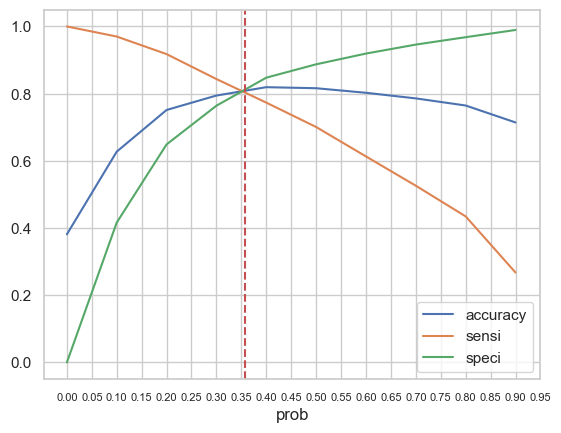

In [121]:
#plotting accuracy, sensitivity and specificity for various probabilities
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.xticks(np.arange(0,1,step=0.05),size=8)
plt.axvline(x=0.358, color='r', linestyle='--')

plt.show()

__From the above curve, it is obvious that 0.358 is the optimal cutoff point.__

In [122]:
#calculating 'final_predicted' based on 'Converted_Prob' using 0.358 cutoff
y_train_pred_final['final_predicted'] = y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.358 else 0)

In [123]:
#dropping the unnecessary columns
y_train_pred_final.drop([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9], axis = 1, inplace = True) 

In [124]:
#displaying the head
y_train_pred_final.head() 

,Converted,Converted_Prob,Prospect ID,final_predicted
0,0,0.586909,1871,1
1,0,0.081804,6795,0
2,0,0.359724,3516,1
3,0,0.791514,8105,1
4,0,0.305038,3934,0


In [125]:
#assigning 'Lead_Score' based on 'Converted_Prob'
y_train_pred_final['Lead_Score'] = y_train_pred_final.Converted_Prob.map(lambda x: round(x*100))

In [126]:
#selecting only important columns and displaying head of dataframe
y_train_pred_final[['Converted','Converted_Prob','Prospect ID','final_predicted','Lead_Score']].head()

,Converted,Converted_Prob,Prospect ID,final_predicted,Lead_Score
0,0,0.586909,1871,1,59
1,0,0.081804,6795,0,8
2,0,0.359724,3516,1,36
3,0,0.791514,8105,1,79
4,0,0.305038,3934,0,31


### Model Evaluation

A confusion matrix is a performance measurement tool which provides a comprehensive view of how well your model is performing by summarizing the results of actual versus predicted.

In [127]:
#confusion matrix
confusion_mat = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_predicted)
print(confusion_mat)

[[3293  709]
 [ 498 1968]]


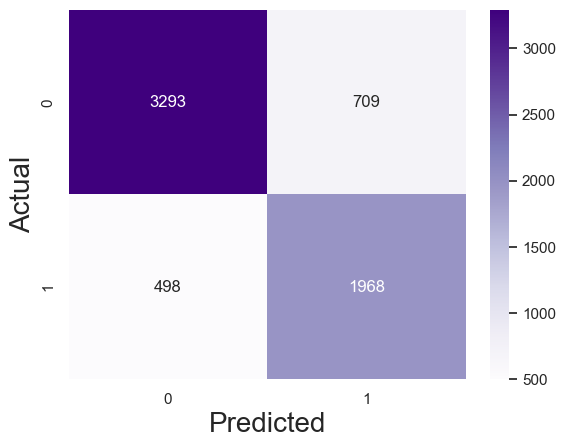

In [128]:
#plotting the confusion matrix
sns.heatmap(confusion_mat, annot=True,fmt='g',cmap='Purples')
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.show()

In [129]:
#check the overall accuracy
metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.8133889919604206

In [130]:
TP = confusion_mat[1,1] #true positive 
TN = confusion_mat[0,0] #true negatives
FP = confusion_mat[0,1] #false positives
FN = confusion_mat[1,0] #false negatives

In [131]:
#checking the sensitivity of our model
TP / float(TP+FN)

0.7980535279805353

In [132]:
#specificity
TN / float(TN+FP)

0.8228385807096452

In [133]:
#calculating False Postive Rate
print(FP/ float(TN+FP))

0.1771614192903548


In [134]:
#positive predictive value
print (TP / float(TP+FP))

0.7351512887560703


In [135]:
#negative predictive value
print (TN / float(TN+ FN))

0.8686362437351622


### Precision and Recall

In [136]:
#precision
confusion_mat[1,1]/(confusion_mat[0,1]+confusion_mat[1,1])

0.7351512887560703

In [137]:
#recall
confusion_mat[1,1]/(confusion_mat[1,0]+confusion_mat[1,1])

0.7980535279805353

In [138]:
#Importing required libraries
from sklearn.metrics import precision_score, recall_score

#calculating precision value
precision_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.7351512887560703

In [139]:
#calculating recall value
recall_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.7980535279805353

So, the values are as follows for the 'train' Data

- Accuracy :    81%
- Sensitivity : 79%
- Specificity : 82%
- Precision:    73%
- Recall:       79%

### Plotting ROC Curve

An ROC curve demonstrates several things:

- It shows the tradeoff between sensitivity and specificity (any increase in sensitivity will be accompanied by a decrease in specificity).
- The closer the curve follows the left-hand border and then the top border of the ROC space, the more accurate the test.
- The closer the curve comes to the 45-degree diagonal of the ROC space, the less accurate the test.

In [140]:
def draw_roc(actual, probs):
    fpr, tpr, thresholds = metrics.roc_curve(actual, probs, drop_intermediate = False)
    auc_score = metrics.roc_auc_score(actual, probs)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    return None

In [141]:
fpr, tpr, thresholds = metrics.roc_curve(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob, drop_intermediate = False)

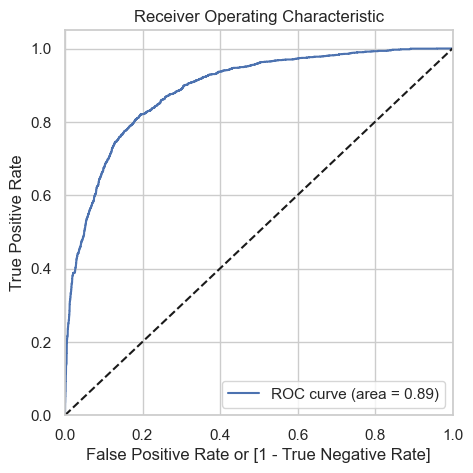

In [142]:
draw_roc(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

We got a value of __0.89__ which means that ours is a good model.

### Precision - Recall

In [143]:
#importing required library
from sklearn.metrics import precision_recall_curve

In [144]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

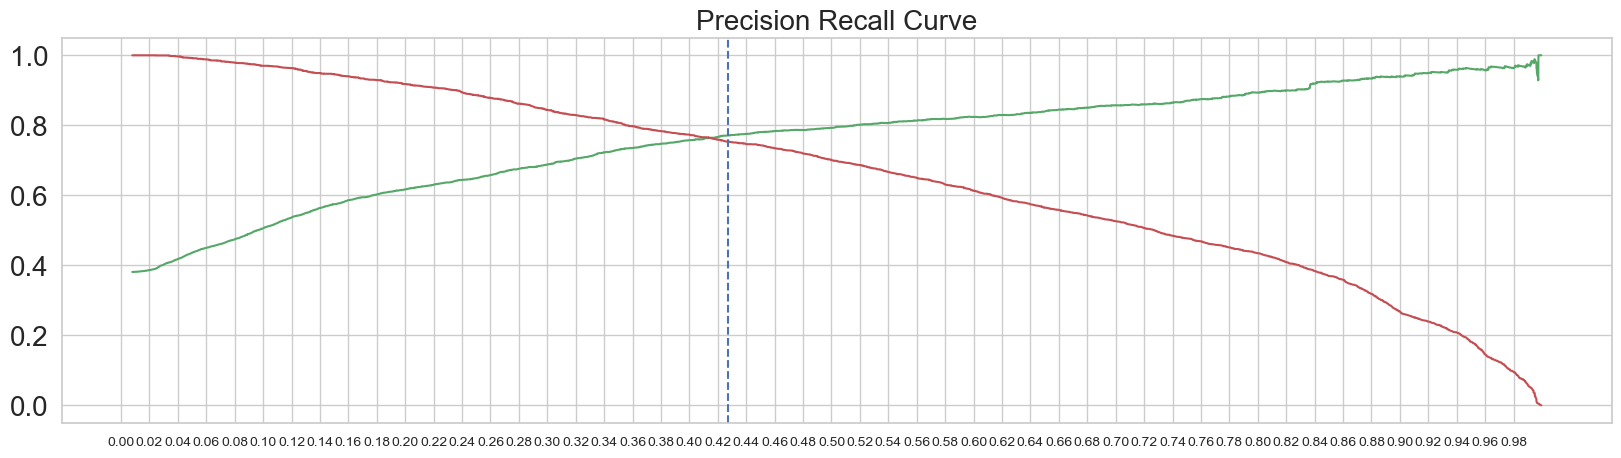

In [145]:
plt.figure(figsize=(20,5))
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")
plt.title('Precision Recall Curve',fontsize=20)
plt.axvline(x=0.427, color='b', linestyle='--') # additing axline
plt.xticks(np.arange(0,1,step=0.02),size=10)
plt.yticks(size=20)

plt.show()

From the above we can see that cutoff point is 0.427.

Now, we will use this threshold value from 'Precision Recall Tradeoff Curve' for Data Evaluation

In [146]:
# plotting the train dataset again with cutoff 0.427
y_train_pred_final['final_predicted_2'] = y_train_pred_final['Converted_Prob'].map(lambda x: 1 if x > 0.427 else 0)
y_train_pred_final.head()

,Converted,Converted_Prob,Prospect ID,final_predicted,Lead_Score,final_predicted_2
0,0,0.586909,1871,1,59,1
1,0,0.081804,6795,0,8,0
2,0,0.359724,3516,1,36,0
3,0,0.791514,8105,1,79,1
4,0,0.305038,3934,0,31,0


In [147]:
#confusion matrix
confusion_mat2 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_predicted_2)
print(confusion_mat2)

[[3450  552]
 [ 607 1859]]


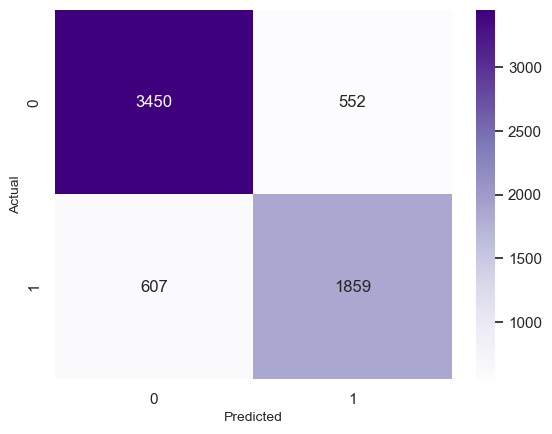

In [148]:
#plotting confusion matrix
sns.heatmap(confusion_mat2, annot=True, fmt='g', cmap='Purples')
plt.xlabel('Predicted',fontsize=10)
plt.ylabel('Actual',fontsize=10)
plt.show()

In [149]:
#overall accuracy
metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted_2)

0.8208101422387136

In [150]:
TP = confusion_mat2[1,1] # true positive 
TN = confusion_mat2[0,0] # true negatives
FP = confusion_mat2[0,1] # false positives
FN = confusion_mat2[1,0] # false negatives

In [151]:
#sensitivity
TP / float(TP+FN)

0.7538523925385239

In [152]:
#specificity
TN / float(TN+FP)

0.8620689655172413

In [153]:
#positive predictive value
print (TP / float(TP+FP))

0.771049357113231


In [154]:
#negative predictive value
print (TN / float(TN+ FN))

0.8503820557061869


In [155]:
#precision
confusion_mat2[1,1]/(confusion_mat2[0,1]+confusion_mat2[1,1])

0.771049357113231

In [156]:
#recall
confusion_mat2[1,1]/(confusion_mat2[1,0]+confusion_mat2[1,1])

0.7538523925385239

By using the Precision - Recall trade off curve cut off point True Positive number has decrease and True Negative number has increase

Thus, we cannot use Precision-Recall trade-off method as it reduced True Positive so 'Recall'/'sensitivity' decreased for this point We have to increase Sensitivity Recall value to increase True Positives. Thus we will use 0.358 as optimal cutoff point.

### Predictions on 'test' Dataset

In [157]:
#applying 'transform' to scale the 'test' data
X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.transform(X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])

In [158]:
#predicting using the model i.e. logm
test_col = X_train_sm.columns
X_test=X_test[test_col[1:]]

#adding constant variable
X_test = sm.add_constant(X_test)

X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2772 entries, 4269 to 2960
Data columns (total 16 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   const                                                 2772 non-null   float64
 1   Lead Origin_Landing Page Submission                   2772 non-null   bool   
 2   Lead Origin_Lead Add Form                             2772 non-null   bool   
 3   Lead Source_Olark Chat                                2772 non-null   bool   
 4   Lead Source_Reference                                 2772 non-null   bool   
 5   Last Activity_Email Opened                            2772 non-null   bool   
 6   Last Activity_Olark Chat Conversation                 2772 non-null   bool   
 7   Last Activity_Page Visited on Website                 2772 non-null   bool   
 8   Last Activity_SMS Sent                                2772 n

In [159]:
X_test.dtypes

const                                                   float64
Lead Origin_Landing Page Submission                        bool
Lead Origin_Lead Add Form                                  bool
Lead Source_Olark Chat                                     bool
Lead Source_Reference                                      bool
Last Activity_Email Opened                                 bool
Last Activity_Olark Chat Conversation                      bool
Last Activity_Page Visited on Website                      bool
Last Activity_SMS Sent                                     bool
What is your current occupation_Other                      bool
What is your current occupation_Unemployed                 bool
What is your current occupation_Working Professional       bool
Specialization_Other                                       bool
Lead Number                                               int64
Total Time Spent on Website                             float64
A free copy of Mastering The Interview  

In [160]:
X_test = X_test.astype({col: 'int' for col in X_test.select_dtypes(include=['bool']).columns})

In [161]:
X_test.dtypes

const                                                   float64
Lead Origin_Landing Page Submission                       int32
Lead Origin_Lead Add Form                                 int32
Lead Source_Olark Chat                                    int32
Lead Source_Reference                                     int32
Last Activity_Email Opened                                int32
Last Activity_Olark Chat Conversation                     int32
Last Activity_Page Visited on Website                     int32
Last Activity_SMS Sent                                    int32
What is your current occupation_Other                     int32
What is your current occupation_Unemployed                int32
What is your current occupation_Working Professional      int32
Specialization_Other                                      int32
Lead Number                                               int64
Total Time Spent on Website                             float64
A free copy of Mastering The Interview  

In [162]:
#predictions on test data
y_test_pred = logm.predict(X_test)

In [163]:
#checking
y_test_pred[:10]

4269    0.496662
2376    0.890557
7766    0.599378
9199    0.070036
4359    0.852923
9186    0.515840
1631    0.567531
8963    0.135066
8007    0.028644
5324    0.367928
dtype: float64

In [164]:
#converting y_test_pred into a df
y_pred_df = pd.DataFrame(y_test_pred)

In [165]:
#converting y_test to dataframe
y_test_df = pd.DataFrame(y_test)

In [166]:
#putting 'Prospect ID' to index
y_test_df['Prospect ID'] = y_test_df.index

In [167]:
#removing index for both dfs to append them horizintally
y_pred_df.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)

In [168]:
#appending y_test_df and y_pred_df
y_pred_final = pd.concat([y_test_df, y_pred_df],axis=1)

In [169]:
#displaying head of 'y_pred_final'
y_pred_final.head()

,Converted,Prospect ID,0
0,1,4269,0.496662
1,1,2376,0.890557
2,1,7766,0.599378
3,0,9199,0.070036
4,1,4359,0.852923


In [170]:
#renaming column '0' as 'Converted_Prob'
y_pred_final= y_pred_final.rename(columns={ 0 : 'Converted_Prob'})

In [171]:
y_pred_final.head()

,Converted,Prospect ID,Converted_Prob
0,1,4269,0.496662
1,1,2376,0.890557
2,1,7766,0.599378
3,0,9199,0.070036
4,1,4359,0.852923


In [172]:
#assigning 'Lead Score' to df 'y_pred_final'
y_pred_final['Lead_Score'] = y_pred_final.Converted_Prob.map(lambda x: round(x*100))

In [173]:
y_pred_final.head()

,Converted,Prospect ID,Converted_Prob,Lead_Score
0,1,4269,0.496662,50
1,1,2376,0.890557,89
2,1,7766,0.599378,60
3,0,9199,0.070036,7
4,1,4359,0.852923,85


In [174]:
#calculating 'final_predicted' based on 'Converted_Prob' for cutoff 0.358
y_pred_final['final_predicted'] = y_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.358 else 0)

In [175]:
#displaying
y_pred_final.head()

,Converted,Prospect ID,Converted_Prob,Lead_Score,final_predicted
0,1,4269,0.496662,50,1
1,1,2376,0.890557,89,1
2,1,7766,0.599378,60,1
3,0,9199,0.070036,7,0
4,1,4359,0.852923,85,1


### Model Evaluation

In [176]:
#checking accuracy
metrics.accuracy_score(y_pred_final.Converted, y_pred_final.final_predicted)

0.8091630591630592

Calculating confusion matrix for test data as well.

In [177]:
confusion_mat3 = metrics.confusion_matrix(y_pred_final.Converted, y_pred_final.final_predicted )
confusion_mat3

array([[1374,  303],
       [ 226,  869]], dtype=int64)

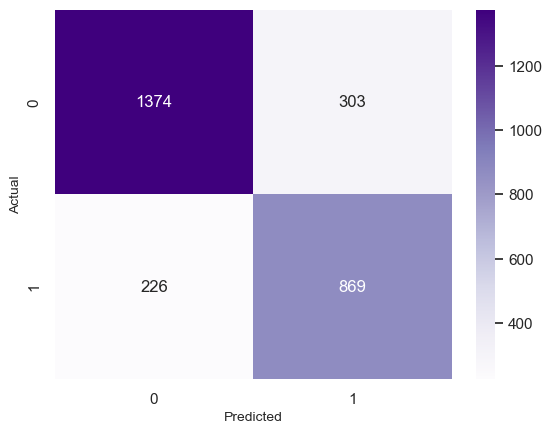

In [178]:
#plotting confusion matrix
sns.heatmap(confusion_mat3, annot=True, fmt='g', cmap='Purples')
plt.xlabel('Predicted',fontsize=10)
plt.ylabel('Actual',fontsize=10)
plt.show()

In [179]:
TP = confusion_mat3[1,1] #true positive 
TN = confusion_mat3[0,0] #true negatives
FP = confusion_mat3[0,1] #false positives
FN = confusion_mat3[1,0] #false negatives

In [180]:
#sensitivity
TP / float(TP+FN)

0.7936073059360731

In [181]:
#specificity
TN / float(TN+FP)

0.8193202146690519

In [182]:
#False Postive Rate
print(FP/ float(TN+FP))

0.1806797853309481


In [183]:
#positive predictive value
print (TP / float(TP+FP))

0.7414675767918089


In [184]:
#negative predictive value
print (TN / float(TN+ FN))

0.85875


In [185]:
#precision
precision_score(y_pred_final.Converted, y_pred_final.final_predicted)

0.7414675767918089

In [186]:
#recall
recall_score(y_pred_final.Converted, y_pred_final.final_predicted)

0.7936073059360731

__Sensitivity values for both train and test datasets is 79%.__     

__Accuracy is ~81% for both the datasets, which means that our model is performing well for test dataset also.__

So, finally, the values for __train__ data are -
- Accuracy : 81%
- Sensitivity : 79%
- Specificity : 82%
- Precision : 73%
- Recall : 79%
    
For __test__ data, the values are -
- Accuracy : 81%
- Sensitivity : 79%
- Specificity : 82%
- Precision : 74%
- Recall : 79%

## 7. Results

Finally, to increase the leads conversion rate of X Education, their sales team should mainly focus on the following important features responsible for good conversion.

- Pursue all leads from 'Lead Source_Welingak Website', as the conversion rate is very high for leads who got to know about X Education from 'Welingak Website'.

- Generate more leads from 'Lead Origin_Lead Add Form'. The leads who have origin from 'Lead Add Form' have higher conversion rate, so the company should focus on getting more number of leads from here.

- Leads whose occupation is 'Working Professional' having highest conversion rate ('What is your current occupation_Working Professional'). Hence the company should focus on getting maximum number of working people as leads, and also pursue them.

- Leads whose last activity is 'SMS Sent' are most likely to convert (Last Activity_SMS Sent)

- Leads spending high time on the company's website are also most likely to convert ('Total Time Spent on Website')



To summarize, our __hot leads__ are:
- Working Professionals
- Leads with last activity as 'SMS Sent'
- Leads who got to know about X Education through 'Welingak Website', and
- Leads having origin from 'Lead Add Form'

If X Education focuses on the above hot leads, its conversion rate and business will definitely improve a lot.